# Bringing the Heat 🔥 — run the complete pipeline in Colab
**Muntaser Syed · [muntasersyed.com](https://muntasersyed.com)**

**Hub → reproducible dataset → PEFT LoRA + Accelerate → Optimum ONNX INT8 → evaluation → release gate → inference.**

1. Use **Runtime → Change runtime type → T4 GPU** if available. CPU also works, but full training is substantially slower. This notebook does not use a TPU.
2. Choose **Runtime → Run all**. The first run installs the teaching libraries and downloads public model/data files. Every stage runs for real; there are no precomputed metrics or training bypasses.
3. For a 30-minute presentation, run it beforehand and narrate the saved results. Keep the notebook open while it executes; Colab resources and GPUs are not guaranteed.

No Hugging Face token, Drive mount, paid API, or public web server is required. The notebook carries its own version of the source files. Its outputs live in the current runtime and can be downloaded at the end.

**The task:** classify news as World, Sports, Business or Sci/Tech. This small model makes the engineering workflow visible; the recipe is not an LLM or a claim of production readiness.


## 0 · Set the contract before seeing results
We use the same 3,200 training / 400 validation / 800 locked test examples as the talk.

The Colab **teaching** policy is separate from the presenter's laptop policy: two CPU benchmark threads and a fixed illustrative 250 ms p95 budget on this VM. Hardware and timing are recorded with every run. This is not an edge-device measurement or a product SLA. For a real release, freeze a budget for your actual serving hardware before evaluation.

Keep three epochs for the complete exercise. A gate that returns **BLOCK** is a valid measurement outcome: do not lower thresholds after looking at the test. New experiments should use validation; repeated tuning against this test invalidates it as a heldout decision set.


In [1]:
from pathlib import Path
import datetime, hashlib, importlib.metadata, json, os, platform, site, subprocess, sys, time, zipfile
from IPython.display import display, Markdown, Image

EPOCHS = 3
BATCH_SIZE = 32
BENCHMARK_THREADS = 2
# Change policy only before a fresh experiment, not in response to test results.
CPU_P95_BUDGET_MS = 250.0
RUN_LABEL = datetime.datetime.now(datetime.timezone.utc).strftime('%Y%m%d-%H%M%S-%f')
BASE = Path('/content') if Path('/content').is_dir() else Path.cwd()
WORK = BASE / f'bringing-the-heat-{RUN_LABEL}'
WORK.mkdir(parents=True, exist_ok=False)
print('Run folder:', WORK)
print('Notebook Python:', platform.python_version())

# Child processes inherit only task controls here; no secrets are read or printed.
os.environ['HF_HUB_DISABLE_IMPLICIT_TOKEN'] = '1'
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['USE_TF'] = '0'
os.environ['USE_FLAX'] = '0'
os.environ['PYTHONUNBUFFERED'] = '1'

def read(relative):
    return json.loads((WORK / relative).read_text(encoding='utf-8'))

def command(argv, *, log_name, allowed=(0,)):
    # Stream progress, preserve a log, and propagate every unexpected failure.
    started = time.perf_counter()
    logs = WORK / 'logs'
    logs.mkdir(exist_ok=True)
    with (logs / f'{log_name}.log').open('w', encoding='utf-8') as log:
        process = subprocess.Popen([str(arg) for arg in argv], cwd=WORK,
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
            encoding='utf-8', errors='replace', bufsize=1)
        for line in process.stdout:
            print(line, end='', flush=True)
            log.write(line)
        result = process.wait()
    elapsed = time.perf_counter() - started
    print(f'[{log_name}] exit={result}; elapsed={elapsed:.1f}s')
    if result not in allowed:
        raise RuntimeError(f'{log_name} failed with exit {result}; see output above.')
    return result


Run folder: /content/bringing-the-heat-20260917-181550-581335
Notebook Python: 3.13.15


In [2]:
#@title Materialize the exact demo source bundled with this notebook
# Expand this cell to inspect the complete source. No repository clone is required.
BUNDLED_FILES = {'demo.py': '"""Bringing the Heat: reproducible Hub -> LoRA -> ONNX -> release gate.\n\nRun `python demo.py --help`. All outputs stay beside this script. No uploads.\n"""\nfrom __future__ import annotations\n\nimport argparse\nimport hashlib\nimport importlib.metadata\nimport json\nimport math\nimport os\nimport platform\nimport random\nimport statistics\nimport sys\nimport time\nfrom pathlib import Path\n\nos.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")\nos.environ.setdefault("TOKENIZERS_PARALLELISM", "false")\nos.environ.setdefault("HF_HUB_DISABLE_IMPLICIT_TOKEN", "1")\nROOT = Path(__file__).resolve().parent\nART = ROOT / "artifacts"\nRESULTS = ROOT / "results"\nLABELS = ["World", "Sports", "Business", "Sci/Tech"]\nSEED = 42\nMAX_LENGTH = 128\n\n\ndef write_json(path, value):\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    path.write_text(json.dumps(value, indent=2, ensure_ascii=False) + "\\n", encoding="utf-8")\n\n\ndef read_json(path):\n    return json.loads(Path(path).read_text(encoding="utf-8"))\n\n\ndef sha(path):\n    h = hashlib.sha256()\n    with Path(path).open("rb") as f:\n        for chunk in iter(lambda: f.read(1 << 20), b""):\n            h.update(chunk)\n    return h.hexdigest()\n\n\ndef text_hash(text):\n    return hashlib.sha256(" ".join(text.lower().split()).encode()).hexdigest()\n\n\ndef manifest():\n    return read_json(ART / "manifest.json")\n\n\ndef rows(split):\n    path = ART / "data" / f"{split}.jsonl"\n    expected = manifest()["splits"][split]["sha256"]\n    if sha(path) != expected:\n        raise RuntimeError(f"{split} checksum changed; refusing to use an altered split")\n    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines()]\n\n\ndef environment():\n    import torch\n    names = ["torch", "transformers", "peft", "accelerate", "datasets", "optimum-onnx", "onnxruntime", "scikit-learn", "gradio"]\n    def version(name):\n        try:\n            return importlib.metadata.version(name)\n        except importlib.metadata.PackageNotFoundError:\n            return None  # The Colab notebook uses inline inference without Gradio.\n    return {"python": platform.python_version(), "platform": platform.platform(),\n            "processor": platform.processor(), "cpu_logical_count": os.cpu_count(),\n            "cuda_available": torch.cuda.is_available(),\n            "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,\n            "packages": {name: version(name) for name in names}}\n\n\ndef prepare(args):\n    """Download public, immutable revisions; make disjoint, balanced splits once."""\n    from datasets import load_dataset\n    from huggingface_hub import HfApi, snapshot_download\n    if (ART / "manifest.json").exists():\n        print("Prepared manifest already exists. Run preflight to verify it; preserved unchanged.")\n        return\n    api = HfApi(token=False)\n    pins_path = ROOT / "hub_revisions.json"\n    if pins_path.exists():\n        pins = read_json(pins_path)\n    else:\n        pins = {"model_id": "distilbert/distilbert-base-uncased", "dataset_id": "fancyzhx/ag_news"}\n        pins["model_revision"] = api.model_info(pins["model_id"]).sha\n        pins["dataset_revision"] = api.dataset_info(pins["dataset_id"]).sha\n        write_json(pins_path, pins)\n    ART.mkdir(exist_ok=True)\n    snapshot_download(pins["model_id"], revision=pins["model_revision"], token=False,\n                      local_dir=ART / "base_model",\n                      allow_patterns=["config.json", "model.safetensors", "tokenizer.json", "tokenizer_config.json", "vocab.txt"])\n    ds = load_dataset(pins["dataset_id"], revision=pins["dataset_revision"], token=False)\n    # Exact-normalized-text deduplication also blocks exact cross-split duplicates.\n    seen = set()\n    def select(source, count, source_name, rng_seed):\n        indices = list(range(len(source)))\n        random.Random(rng_seed).shuffle(indices)\n        counts = [0] * 4\n        selected = []\n        for index in indices:\n            row = source[index]\n            label, fingerprint = int(row["label"]), text_hash(row["text"])\n            if counts[label] >= count // 4 or fingerprint in seen:\n                continue\n            seen.add(fingerprint)\n            counts[label] += 1\n            selected.append({"id": f"{source_name}:{index}", "text": row["text"], "label": label,\n                             "text_sha256": fingerprint})\n            if len(selected) == count:\n                break\n        if len(selected) != count:\n            raise RuntimeError("Not enough unique data for the requested balanced split")\n        return selected\n    partitions = {"train": select(ds["train"], 3200, "train", SEED),\n                  "validation": select(ds["train"], 400, "train", SEED + 1),\n                  "test": select(ds["test"], 800, "test", SEED + 2)}\n    split_metadata = {}\n    (ART / "data").mkdir(exist_ok=True)\n    for name, items in partitions.items():\n        p = ART / "data" / f"{name}.jsonl"\n        p.write_text("\\n".join(json.dumps(item, ensure_ascii=False) for item in items) + "\\n", encoding="utf-8")\n        split_metadata[name] = {"count": len(items), "sha256": sha(p), "class_counts": [sum(r["label"] == i for r in items) for i in range(4)]}\n    write_json(ART / "manifest.json", {**pins, "seed": SEED, "max_length": MAX_LENGTH,\n        "labels": LABELS, "splits": split_metadata,\n        "split_policy": "Balanced fixed subsets; validation from official train, test from official test; normalized exact-text deduplication across all subsets. Near duplicates are not detected.",\n        "policy_sha256": sha(ROOT / "release_policy.json"), "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())})\n    print(json.dumps(manifest(), indent=2))\n\n\ndef preflight(args):\n    import torch\n    from transformers import AutoTokenizer\n    data = {name: rows(name) for name in ("train", "validation", "test")}\n    sets = {name: {r["text_sha256"] for r in values} for name, values in data.items()}\n    assert not (sets["train"] & sets["validation"] or sets["train"] & sets["test"] or sets["validation"] & sets["test"])\n    assert sha(ROOT / "release_policy.json") == manifest()["policy_sha256"], "Release policy changed after preparation"\n    AutoTokenizer.from_pretrained(ART / "base_model", local_files_only=True)\n    assert (ART / "base_model" / "model.safetensors").exists()\n    report = {"status": "PASS", "environment": environment(), "split_integrity": "PASS",\n              "cpu_threads_for_benchmark": read_json(ROOT / "release_policy.json").get("benchmark_threads", 4), "cuda_smoke": None}\n    if torch.cuda.is_available():\n        report["cuda_smoke"] = float((torch.ones((32, 32), device="cuda") @ torch.ones((32, 32), device="cuda"))[0, 0])\n    write_json(RESULTS / "preflight.json", report)\n    print(json.dumps(report, indent=2))\n\n\ndef make_loader(items, tokenizer, batch_size=32, shuffle=False):\n    from datasets import Dataset\n    from torch.utils.data import DataLoader\n    from transformers import DataCollatorWithPadding\n    ds = Dataset.from_list(items)\n    ds = ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LENGTH), batched=True,\n                remove_columns=["id", "text", "text_sha256"])\n    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0,\n                      collate_fn=DataCollatorWithPadding(tokenizer))\n\n\ndef metrics(labels, predictions):\n    from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support\n    p, r, f, n = precision_recall_fscore_support(labels, predictions, labels=list(range(4)), zero_division=0)\n    accuracy = float(accuracy_score(labels, predictions))\n    # Wilson interval makes the heldout set\'s sampling uncertainty visible.\n    z, count = 1.96, len(labels)\n    center = (accuracy + z * z / (2 * count)) / (1 + z * z / count)\n    half = z * math.sqrt(accuracy * (1 - accuracy) / count + z * z / (4 * count * count)) / (1 + z * z / count)\n    return {"n": count, "accuracy": accuracy, "macro_f1": float(f.mean()),\n        "accuracy_95pct_wilson": [center - half, center + half],\n        "per_class": {name: {"precision": float(p[i]), "recall": float(r[i]), "f1": float(f[i]), "support": int(n[i])} for i, name in enumerate(LABELS)},\n        "confusion_matrix": confusion_matrix(labels, predictions, labels=list(range(4))).tolist()}\n\n\ndef train(args):\n    import torch\n    from accelerate import Accelerator\n    from accelerate.utils import set_seed\n    from peft import LoraConfig, TaskType, get_peft_model\n    from transformers import AutoModelForSequenceClassification, AutoTokenizer\n    torch.set_num_threads(4)\n    accelerator = Accelerator(cpu=args.cpu, mixed_precision="no")\n    set_seed(SEED)\n    tokenizer = AutoTokenizer.from_pretrained(ART / "base_model", local_files_only=True)\n    base = AutoModelForSequenceClassification.from_pretrained(ART / "base_model", num_labels=4,\n        id2label=dict(enumerate(LABELS)), label2id={label: i for i, label in enumerate(LABELS)},\n        local_files_only=True, attn_implementation="eager")\n    config = LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,\n        target_modules=["q_lin", "v_lin"], modules_to_save=["pre_classifier", "classifier"])\n    model = get_peft_model(base, config)\n    trainable, total = model.get_nb_trainable_parameters()\n    accelerator.print(f"Trainable: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")\n    train_loader = make_loader(rows("train"), tokenizer, args.batch_size, shuffle=True)\n    validation_loader = make_loader(rows("validation"), tokenizer, args.batch_size)\n    optimizer = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=args.learning_rate)\n    model, optimizer, train_loader, validation_loader = accelerator.prepare(model, optimizer, train_loader, validation_loader)\n    started, history, best = time.perf_counter(), [], -1.0\n    num_epochs = 1 if args.smoke else args.epochs\n    output_name = "smoke_adapter" if args.smoke else "adapter"\n    for epoch in range(num_epochs):\n        model.train()\n        losses = []\n        for step, batch in enumerate(train_loader):\n            optimizer.zero_grad()\n            loss = model(**batch).loss\n            accelerator.backward(loss)\n            optimizer.step()\n            losses.append(float(loss.detach()))\n            if step % 25 == 0:\n                accelerator.print(f"Epoch {epoch + 1}/{num_epochs} step {step}/{len(train_loader)} loss={losses[-1]:.4f}", flush=True)\n            if args.smoke and step >= 4:\n                break\n        model.eval()\n        ys, ps = [], []\n        with torch.inference_mode():\n            for batch in validation_loader:\n                pred, target = accelerator.gather_for_metrics((model(**batch).logits.argmax(-1), batch["labels"]))\n                ps.extend(pred.cpu().tolist())\n                ys.extend(target.cpu().tolist())\n        score = metrics(ys, ps)\n        history.append({"epoch": epoch + 1, "mean_loss": statistics.mean(losses), "validation": score})\n        accelerator.print(f"Validation macro F1: {score[\'macro_f1\']:.4f}")\n        if score["macro_f1"] > best:\n            best = score["macro_f1"]\n            accelerator.wait_for_everyone()\n            state = accelerator.get_state_dict(model)\n            if accelerator.is_main_process:\n                unwrapped = accelerator.unwrap_model(model)\n                unwrapped.save_pretrained(ART / output_name, state_dict=state)\n                tokenizer.save_pretrained(ART / output_name)\n        accelerator.wait_for_everyone()\n    if accelerator.is_main_process:\n        write_json(RESULTS / ("smoke_training.json" if args.smoke else "training.json"), {"environment": environment(), "seconds": time.perf_counter() - started,\n            "seed": SEED, "epochs": num_epochs, "smoke_only": args.smoke, "learning_rate": args.learning_rate,\n            "per_device_batch_size": args.batch_size, "world_size": accelerator.num_processes,\n            "effective_batch_size": args.batch_size * accelerator.num_processes,\n            "trainable_parameters": trainable, "total_parameters": total,\n            "trainable_percent": 100 * trainable / total, "selection": "highest validation macro F1", "history": history})\n\n\ndef export(args):\n    import torch\n    from peft import PeftModel\n    from transformers import AutoModelForSequenceClassification, AutoTokenizer\n    from optimum.onnxruntime import ORTModelForSequenceClassification, ORTQuantizer\n    from optimum.onnxruntime.configuration import AutoQuantizationConfig\n    torch.set_num_threads(4)\n    base = AutoModelForSequenceClassification.from_pretrained(ART / "base_model", num_labels=4,\n        id2label=dict(enumerate(LABELS)), label2id={label: i for i, label in enumerate(LABELS)}, local_files_only=True,\n        attn_implementation="eager")\n    model = PeftModel.from_pretrained(base, ART / "adapter", local_files_only=True).merge_and_unload()\n    model.save_pretrained(ART / "merged")\n    tokenizer = AutoTokenizer.from_pretrained(ART / "base_model", local_files_only=True)\n    tokenizer.save_pretrained(ART / "merged")\n    ort_model = ORTModelForSequenceClassification.from_pretrained(ART / "merged", export=True, provider="CPUExecutionProvider")\n    ort_model.save_pretrained(ART / "onnx_fp32")\n    tokenizer.save_pretrained(ART / "onnx_fp32")\n    quantizer = ORTQuantizer.from_pretrained(ART / "onnx_fp32")\n    factory = getattr(AutoQuantizationConfig, args.target)\n    quantizer.quantize(save_dir=ART / "onnx_int8", quantization_config=factory(is_static=False, per_channel=False))\n    tokenizer.save_pretrained(ART / "onnx_int8")\n    files = {}\n    for name in ["adapter", "merged", "onnx_fp32", "onnx_int8"]:\n        files[name] = {str(p.relative_to(ART / name)): {"bytes": p.stat().st_size, "sha256": sha(p)}\n            for p in (ART / name).rglob("*") if p.is_file() and ".cache" not in p.parts}\n    write_json(RESULTS / "export.json", {"target": args.target, "quantization": "dynamic INT8 weights / runtime activations; embeddings may remain FP32", "artifacts": files})\n    print("Merged adapter, exported ONNX FP32, and generated ONNX dynamic INT8.")\n\n\ndef load_backend(backend, threads=4):\n    import torch\n    from transformers import AutoModelForSequenceClassification, AutoTokenizer\n    torch.set_num_threads(threads)\n    folder = {"pytorch": "merged", "onnx": "onnx_fp32", "int8": "onnx_int8"}[backend]\n    tokenizer = AutoTokenizer.from_pretrained(ART / folder, local_files_only=True)\n    if backend == "pytorch":\n        model = AutoModelForSequenceClassification.from_pretrained(ART / "merged", local_files_only=True,\n            attn_implementation="eager").eval()\n    else:\n        import onnxruntime as ort\n        from optimum.onnxruntime import ORTModelForSequenceClassification\n        options = ort.SessionOptions()\n        options.intra_op_num_threads, options.inter_op_num_threads = threads, 1\n        options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL\n        folder = "onnx_int8" if backend == "int8" else "onnx_fp32"\n        filename = "model_quantized.onnx" if backend == "int8" else "model.onnx"\n        model = ORTModelForSequenceClassification.from_pretrained(ART / folder, file_name=filename,\n            provider="CPUExecutionProvider", session_options=options, local_files_only=True)\n    return model, tokenizer\n\n\ndef artifact_identity(backend):\n    folder = ART / {"pytorch": "merged", "onnx": "onnx_fp32", "int8": "onnx_int8"}[backend]\n    files = {p.relative_to(folder).as_posix(): sha(p) for p in sorted(folder.rglob("*"))\n             if p.is_file() and ".cache" not in p.parts}\n    if not files:\n        raise RuntimeError(f"Missing runtime artifact: {folder}")\n    description = {"files": files, "max_length": MAX_LENGTH, "truncation": True, "label_order": LABELS}\n    return {"sha256": hashlib.sha256(json.dumps(description, sort_keys=True).encode()).hexdigest(), **description}\n\n\ndef evaluate(args):\n    import torch\n    test = rows("test")\n    labels = [r["label"] for r in test]\n    report = {"split": "locked test", "split_sha256": manifest()["splits"]["test"]["sha256"],\n              "models": {}, "environment": environment(), "artifacts": {name: artifact_identity(name) for name in ["pytorch", "onnx", "int8"]}}\n    train_labels = [r["label"] for r in rows("train")]\n    majority_label = max(range(4), key=train_labels.count)\n    report["majority_class_baseline"] = {"chosen_label": LABELS[majority_label],\n        "rule": "Most frequent training label; ties choose lowest label index", **metrics(labels, [majority_label] * len(labels))}\n    for backend in ["pytorch", "onnx", "int8"]:\n        model, tokenizer = load_backend(backend)\n        predictions = []\n        with torch.inference_mode():\n            for i in range(0, len(test), args.batch_size):\n                inputs = tokenizer([r["text"] for r in test[i:i + args.batch_size]], padding=True,\n                    truncation=True, max_length=MAX_LENGTH, return_tensors="pt")\n                predictions.extend(model(**inputs).logits.argmax(-1).tolist())\n        report["models"][backend] = metrics(labels, predictions)\n        write_json(RESULTS / f"predictions_{backend}.json", {"ids": [r["id"] for r in test], "labels": labels, "predictions": predictions})\n        print(f"{backend}: accuracy={report[\'models\'][backend][\'accuracy\']:.4f}, macro F1={report[\'models\'][backend][\'macro_f1\']:.4f}", flush=True)\n        del model\n    write_json(RESULTS / "evaluation.json", report)\n\n\ndef percentile(values, p):\n    ordered = sorted(values)\n    i = (len(values) - 1) * p\n    lo = math.floor(i)\n    return ordered[lo] + (ordered[min(lo + 1, len(values) - 1)] - ordered[lo]) * (i - lo)\n\n\ndef benchmark(args):\n    import torch\n    test = rows("test")\n    # Fixed batch=1, 128-token padded shape for comparable latency; fixed CPU threads.\n    texts = [r["text"] for r in test[:args.samples]]\n    report = {"environment": environment(), "threads": args.threads, "batch_size": 1,\n        "sequence_length": MAX_LENGTH, "samples": len(texts), "warmup": args.warmup,\n        "device": "CPU", "timing_scope": "Tokenization + model forward, sequential batch=1 requests; excludes load, networking and queueing",\n        "split_sha256": manifest()["splits"]["test"]["sha256"], "models": {},\n        "artifacts": {name: artifact_identity(name) for name in ["pytorch", "onnx", "int8"]}}\n    for backend in ["pytorch", "onnx", "int8"]:\n        model, tokenizer = load_backend(backend, args.threads)\n        def infer(text):\n            inputs = tokenizer(text, padding="max_length", max_length=MAX_LENGTH, truncation=True, return_tensors="pt")\n            return model(**inputs).logits\n        with torch.inference_mode():\n            for i in range(args.warmup):\n                infer(texts[i % len(texts)])\n            timings = []\n            for text in texts:\n                started = time.perf_counter_ns()\n                infer(text)\n                timings.append((time.perf_counter_ns() - started) / 1e6)\n        folder = {"pytorch": "merged", "onnx": "onnx_fp32", "int8": "onnx_int8"}[backend]\n        weights_bytes = sum(p.stat().st_size for p in (ART / folder).rglob("*") if p.is_file() and p.suffix in (".safetensors", ".onnx", ".data"))\n        report["models"][backend] = {"latencies_ms": timings, "p50_ms": percentile(timings, .5),\n            "p95_ms": percentile(timings, .95), "mean_ms": statistics.mean(timings),\n            "sequential_requests_per_second": 1000 / statistics.mean(timings), "weights_bytes": weights_bytes}\n        print(f"{backend}: p50={report[\'models\'][backend][\'p50_ms\']:.2f}ms, p95={report[\'models\'][backend][\'p95_ms\']:.2f}ms, weights={weights_bytes / 1024 ** 2:.1f}MiB", flush=True)\n        del model\n    write_json(RESULTS / "benchmark.json", report)\n\n\ndef gate_checks(evaluation, benchmark_report, policy, current_artifacts, current_split_sha):\n    baseline, candidate = evaluation["models"]["pytorch"], evaluation["models"]["int8"]\n    checks = {\n        "same_heldout_split": evaluation["split_sha256"] == benchmark_report["split_sha256"] == current_split_sha,\n        "exact_runtime_artifacts": all(evaluation.get("artifacts", {}).get(name, {}).get("sha256") ==\n            benchmark_report.get("artifacts", {}).get(name, {}).get("sha256") == current_artifacts[name]["sha256"]\n            for name in ["pytorch", "onnx", "int8"]),\n        "complete_class_report": set(candidate["per_class"]) == set(LABELS),\n        "benchmark_protocol": benchmark_report["device"] == "CPU" and benchmark_report["threads"] == policy.get("benchmark_threads", 4)\n            and benchmark_report["batch_size"] == 1 and benchmark_report["sequence_length"] == MAX_LENGTH\n            and benchmark_report["samples"] >= 100 and benchmark_report["warmup"] >= 10\n            and len(benchmark_report["models"]["int8"]["latencies_ms"]) == benchmark_report["samples"],\n        "minimum_test_size": candidate["n"] >= policy["min_test_examples"],\n        "accuracy": candidate["accuracy"] >= policy["min_accuracy"],\n        "macro_f1": candidate["macro_f1"] >= policy["min_macro_f1"],\n        "every_class_recall": min((c["recall"] for c in candidate["per_class"].values()), default=0) >= policy["min_class_recall"],\n        "quantization_f1_regression": baseline["macro_f1"] - candidate["macro_f1"] <= policy["max_macro_f1_drop"],\n        "cpu_p95_latency": benchmark_report["models"]["int8"]["p95_ms"] <= policy["max_cpu_p95_ms"],\n        "weight_size": benchmark_report["models"]["int8"]["weights_bytes"] <= policy["max_weights_bytes"],\n    }\n    return {"passed": all(checks.values()), "checks": checks}\n\n\ndef gate(args):\n    evaluation, bench = read_json(RESULTS / "evaluation.json"), read_json(RESULTS / "benchmark.json")\n    policy = read_json(ROOT / "release_policy.json")\n    if sha(ROOT / "release_policy.json") != manifest()["policy_sha256"]:\n        raise RuntimeError("Release policy changed after preparation; freeze it before observing the heldout test")\n    rows("test")  # Verify the current heldout file, not just matching old report identifiers.\n    identities = {name: artifact_identity(name) for name in ["pytorch", "onnx", "int8"]}\n    if args.inject_failure:\n        # Obvious simulated regression; authentic evaluation stays untouched.\n        evaluation["models"]["int8"]["per_class"]["Business"]["recall"] = 0.10\n    result = {**gate_checks(evaluation, bench, policy, identities, manifest()["splits"]["test"]["sha256"]), "policy": policy,\n              "injected_failure": args.inject_failure, "scope": "Teaching gate on this locked sample and CPU; not a production certification"}\n    name = "gate_deliberate_failure.json" if args.inject_failure else "gate.json"\n    write_json(RESULTS / name, result)\n    print(json.dumps(result, indent=2))\n    return 0 if result["passed"] else 2\n\n\ndef predict(args):\n    """Exercise the exported artifact directly, including in hosted notebooks."""\n    import torch\n    model, tokenizer = load_backend("int8", threads=args.threads)\n    predictions = []\n    for text in args.text:\n        if not text.strip() or len(text) > 10000:\n            raise ValueError("News text must contain 1–10,000 characters")\n        with torch.inference_mode():\n            inputs = tokenizer(text, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")\n            scores = torch.softmax(model(**inputs).logits, dim=-1)[0].tolist()\n        predictions.append({"text": text, "label": LABELS[max(range(len(scores)), key=scores.__getitem__)],\n                            "scores": dict(zip(LABELS, scores))})\n    report = {"backend": "onnx_int8", "artifact": artifact_identity("int8"),\n              "scores_are_calibrated": False, "predictions": predictions}\n    write_json(RESULTS / "inference.json", report)\n    print(json.dumps(report, indent=2))\n\n\ndef main():\n    parser = argparse.ArgumentParser(description=__doc__)\n    subs = parser.add_subparsers(dest="command", required=True)\n    for command, fn in [("prepare", prepare), ("preflight", preflight), ("train", train), ("export", export), ("evaluate", evaluate), ("benchmark", benchmark), ("gate", gate), ("predict", predict)]:\n        p = subs.add_parser(command)\n        p.set_defaults(fn=fn)\n        if command == "train":\n            p.add_argument("--cpu", action="store_true")\n            p.add_argument("--smoke", action="store_true", help="Five training steps; writes separate smoke_adapter, preserves the rehearsed artifacts")\n            p.add_argument("--epochs", type=int, default=3)\n            p.add_argument("--batch-size", type=int, default=32)\n            p.add_argument("--learning-rate", type=float, default=3e-4)\n        elif command == "export":\n            p.add_argument("--target", choices=["avx2", "avx512", "avx512_vnni", "arm64"], default="avx2")\n        elif command == "evaluate":\n            p.add_argument("--batch-size", type=int, default=32)\n        elif command == "benchmark":\n            p.add_argument("--threads", type=int, default=4)\n            p.add_argument("--samples", type=int, default=100)\n            p.add_argument("--warmup", type=int, default=10)\n        elif command == "gate":\n            p.add_argument("--inject-failure", action="store_true")\n        elif command == "predict":\n            p.add_argument("--text", action="append", required=True)\n            p.add_argument("--threads", type=int, default=4)\n    args = parser.parse_args()\n    return args.fn(args) or 0\n\n\nif __name__ == "__main__":\n    sys.exit(main())\n', 'visuals.py': '"""Notebook diagrams and plots. Charts read this run\'s JSON, never canned metrics."""\nfrom __future__ import annotations\n\nimport argparse\nimport json\nfrom pathlib import Path\n\nimport matplotlib\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\nimport numpy as np\nfrom matplotlib.patches import FancyArrowPatch, FancyBboxPatch\nfrom matplotlib.ticker import PercentFormatter\n\nBG, PANEL, FG, MUTED = "#0B1120", "#152139", "#F1F5FA", "#B8C5D9"\nTEAL, HOT, BLUE, GOLD, RED = "#52DECA", "#FF826B", "#83B4FF", "#F4CE72", "#F28193"\nBACKENDS = ["pytorch", "onnx", "int8"]\nNAMES = ["PyTorch FP32", "ONNX FP32", "ONNX INT8"]\nCOLORS = [BLUE, GOLD, TEAL]\nplt.rcParams.update({\n    "font.family": "DejaVu Sans", "font.size": 12, "figure.facecolor": BG,\n    "axes.facecolor": PANEL, "axes.edgecolor": "#41516D", "axes.labelcolor": FG,\n    "text.color": FG, "xtick.color": MUTED, "ytick.color": MUTED,\n    "axes.titleweight": "bold", "axes.titlepad": 16,\n    "grid.color": "#52627C", "grid.alpha": .25,\n    "savefig.facecolor": BG, "svg.fonttype": "none",\n})\n\n\ndef read(root, name):\n    return json.loads((root / name).read_text(encoding="utf-8"))\n\n\ndef canvas(title, subtitle, height=7.8):\n    fig = plt.figure(figsize=(14, height))\n    fig.text(.055, .945, title, fontsize=24, weight="bold", va="top")\n    fig.text(.055, .88, subtitle, fontsize=12, color=MUTED, va="top")\n    return fig\n\n\ndef save(fig, root, name, note):\n    folder = root / "figures"\n    folder.mkdir(exist_ok=True)\n    fig.text(.055, .035, note, color=MUTED, fontsize=10, va="bottom")\n    for ext in ["png", "svg"]:\n        fig.savefig(folder / f"{name}.{ext}", dpi=145)\n    plt.close(fig)\n    print(f"Saved figures/{name}.png and .svg")\n\n\ndef clean(ax, *, grid="y"):\n    ax.spines[["top", "right"]].set_visible(False)\n    ax.set_axisbelow(True)\n    if grid:\n        ax.grid(axis=grid)\n\n\ndef box(ax, x, y, w, h, title, detail="", color=TEAL, size=14):\n    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.15",\n        facecolor=PANEL, edgecolor=color, linewidth=1.7))\n    ax.text(x+w/2, y+h*.66 if detail else y+h/2, title, fontsize=size,\n        ha="center", va="center", color=FG, weight="bold")\n    if detail:\n        ax.text(x+w/2, y+h*.28, detail, fontsize=10.5, ha="center", va="center", color=MUTED)\n\n\ndef arrow(ax, start, end, color=MUTED, **kwargs):\n    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=17,\n        linewidth=1.7, color=color, **kwargs))\n\n\ndef workflow(root):\n    fig = canvas("One experiment. An engineering handoff.",\n        "Conceptual workflow • inputs and policy are frozen before training and heldout evaluation")\n    ax = fig.add_axes([.05, .16, .90, .65]); ax.set(xlim=(0, 14), ylim=(0, 5)); ax.axis("off")\n    xs, w, h = [.15, 3.65, 7.15, 10.65], 3.15, 1.25\n    top = [("01  Hub", "Pin model + dataset revisions", BLUE),\n           ("02  Datasets", "Split, deduplicate, checksum", BLUE),\n           ("03  PEFT + Accelerate", "Train adapter; select on validation", HOT),\n           ("04  Optimum", "Merge → ONNX → INT8", GOLD)]\n    bottom = [("08  Inference", "Inspect the packaged artifact", TEAL),\n              ("07  Release gate", "PASS or BLOCK from evidence", TEAL),\n              ("06  Benchmark", "CPU latency + footprint", GOLD),\n              ("05  Evaluate", "Same locked test; three runtimes", HOT)]\n    for row, y in [(top, 3.3), (bottom, .6)]:\n        for x, (title, detail, color) in zip(xs, row):\n            box(ax, x, y, w, h, title, detail, color, 12.5)\n    for i in range(3):\n        arrow(ax, (xs[i]+w, 3.925), (xs[i+1], 3.925))\n        arrow(ax, (xs[i+1], 1.225), (xs[i]+w, 1.225))\n    arrow(ax, (xs[-1]+w/2, 3.3), (xs[-1]+w/2, 1.85))\n    ax.text(5.4, 2.45, "Every transition produces a versioned artifact or report",\n            fontsize=12, ha="center", color=MUTED)\n    save(fig, root, "01_workflow", "Conceptual diagram • a passed teaching gate is one input to a real deployment decision, not production certification.")\n\n\ndef splits(root):\n    manifest = read(root, "artifacts/manifest.json")\n    parts = manifest["splits"]\n    fig = canvas("Separate learning from the release decision.",\n        "Actual prepared splits • balanced subsets, normalized exact-text deduplication, saved checksums")\n    ax = fig.add_axes([.05, .14, .56, .66]); ax.set(xlim=(0, 10), ylim=(0, 7)); ax.axis("off")\n    box(ax, .15, 5.4, 3.25, 1.15, "Official train split", "AG News", BLUE)\n    box(ax, .15, .6, 3.25, 1.15, "Official test split", "AG News", GOLD)\n    for name, y, title, purpose, color in [\n        ("train", 5.4, "Training", "Fit LoRA + heads", HOT),\n        ("validation", 3.0, "Validation", "Select checkpoint", BLUE),\n        ("test", .6, "Locked test", "One final evaluation", TEAL)]:\n        box(ax, 5.7, y, 4.0, 1.15, f"{title} · {parts[name][\'count\']:,}", purpose, color)\n    arrow(ax, (3.4, 5.975), (5.7, 5.975))\n    arrow(ax, (3.4, 5.6), (5.7, 3.8), connectionstyle="arc3,rad=.12")\n    arrow(ax, (3.4, 1.175), (5.7, 1.175))\n    ax.text(4.95, 2.45, "No test-to-training arrow", color=TEAL, fontsize=12, ha="center")\n    ax2 = fig.add_axes([.70, .24, .24, .48])\n    labels = manifest["labels"]\n    counts = np.array([parts[name]["class_counts"] for name in ["train", "validation", "test"]])\n    bottoms = np.zeros(3)\n    for j, color in enumerate([BLUE, TEAL, GOLD, HOT]):\n        ax2.bar([0, 1, 2], counts[:, j], bottom=bottoms, color=color, width=.65, label=labels[j])\n        bottoms += counts[:, j]\n    ax2.set_xticks([0, 1, 2], ["Train", "Validation", "Test"], fontsize=10)\n    ax2.set_ylabel("Examples"); ax2.set_ylim(0, max(bottoms)*1.18)\n    for x, count in enumerate(bottoms):\n        ax2.text(x, count+70, f"{int(count):,}", ha="center", weight="bold")\n    ax2.legend(loc="upper center", bbox_to_anchor=(.5, -.17), ncol=2,\n               frameon=False, labelcolor=FG, fontsize=10)\n    clean(ax2)\n    save(fig, root, "02_splits", "Measured counts from artifacts/manifest.json • exact duplicates are excluded; near-duplicate and time/source leakage need additional checks.")\n\n\ndef training(root):\n    report = read(root, "results/training.json")\n    fig = canvas("Freeze the large weights. Learn a small update.",\n        "LoRA concept at an attention projection • measured parameter budget includes the trained classification heads")\n    ax = fig.add_axes([.045, .16, .59, .64]); ax.set(xlim=(0, 11), ylim=(0, 6)); ax.axis("off")\n    ax.text(.25, 3.1, "x", fontsize=24, ha="center")\n    box(ax, 2.1, 3.85, 5.8, 1.2, "Frozen base W", "Original projection weights", BLUE)\n    box(ax, 2.1, 1.2, 2.6, 1.25, "A", "Down-project to rank 8", HOT)\n    box(ax, 5.3, 1.2, 2.6, 1.25, "B", "Up-project", HOT)\n    for start, end in [((.7,3.2),(2.1,4.45)),((.7,3.0),(2.1,1.825)),\n                       ((4.7,1.825),(5.3,1.825)),((7.9,4.45),(9.25,3.35)),\n                       ((7.9,1.825),(9.25,2.9)),((9.9,3.1),(10.75,3.1))]:\n        arrow(ax,start,end)\n    ax.text(9.55,3.1,"+",fontsize=28,ha="center",va="center",color=TEAL)\n    ax.text(10.8,3.1,"y",fontsize=24,ha="center",va="center")\n    ax.text(5,.35,"y = Wx + (α/r) BAx",ha="center",fontsize=16,color=TEAL)\n    trainable, total = report["trainable_parameters"], report["total_parameters"]\n    fraction = trainable / total\n    ax2 = fig.add_axes([.70,.32,.23,.38]); ax2.set_facecolor(BG)\n    ax2.pie([fraction,1-fraction],colors=[HOT,"#2C3C58"],startangle=90,counterclock=False,\n        wedgeprops={"width":.22,"edgecolor":BG})\n    ax2.text(0,.1,f"{100*fraction:.2f}%",ha="center",va="center",fontsize=27,weight="bold",color=HOT)\n    ax2.text(0,-.22,"trainable",ha="center",fontsize=12,color=MUTED)\n    fig.text(.815,.23,f"{trainable:,} / {total:,} parameters",ha="center",fontsize=12)\n    fig.text(.815,.17,"LoRA adapters + classification heads",ha="center",fontsize=10,color=MUTED)\n    save(fig,root,"03_lora_budget","Conceptual LoRA path; counts from this run • frozen does not mean free: base weights still require memory and computation.")\n\n    history=report["history"]; epochs=[x["epoch"] for x in history]\n    losses=[x["mean_loss"] for x in history]; scores=[x["validation"]["macro_f1"] for x in history]\n    best=int(np.argmax(scores))\n    fig=canvas("Let validation choose the checkpoint.",\n        "Measured epoch history • training loss and validation quality are different signals")\n    axes=fig.subplots(1,2); fig.subplots_adjust(left=.08,right=.95,bottom=.18,top=.76,wspace=.24)\n    for ax, values, color, title, ylabel in zip(axes,[losses,scores],[HOT,TEAL],\n        ["Training loss","Validation macro F1"],["Mean cross-entropy loss","Macro F1"]):\n        ax.plot(epochs,values,"o-",color=color,lw=3,markersize=9)\n        ax.set(title=title,xlabel="Epoch",ylabel=ylabel,xticks=epochs)\n        clean(ax)\n        for x,y in zip(epochs,values):\n            ax.annotate(f"{y:.3f}",(x,y),xytext=(0,13),textcoords="offset points",ha="center",color=color)\n    axes[0].set_ylim(0,max(losses)*1.25)\n    axes[1].set_ylim(max(0,min(scores)-.045),min(1,max(scores)+.045))\n    axes[1].axvline(epochs[best],color=TEAL,alpha=.35,ls="--")\n    axes[1].scatter([epochs[best]],[scores[best]],s=280,facecolors="none",edgecolors=TEAL,lw=2)\n    axes[1].text(.04,.08,f"Selected: epoch {epochs[best]}",transform=axes[1].transAxes,color=TEAL,weight="bold")\n    save(fig,root,"04_training_progress","Measured from results/training.json • the validation F1 axis is zoomed for comparison; heldout test scores do not select this checkpoint.")\n\n\ndef export(root):\n    report=read(root,"results/export.json")\n    keys=["adapter","merged","onnx_fp32","onnx_int8"]\n    values=[sum(v["bytes"] for v in report["artifacts"][key].values())/1024**2 for key in keys]\n    fig=canvas("The adapter is small. The runtime must stand alone.",\n        "Measured packaged size • adapter → merged model → ONNX FP32 → ONNX INT8")\n    ax=fig.add_axes([.24,.20,.69,.56])\n    bars=ax.barh(range(4),values,color=[HOT,BLUE,GOLD,TEAL],height=.55)\n    ax.set_yticks(range(4),["LoRA adapter*","Merged model","ONNX FP32","ONNX INT8"])\n    ax.invert_yaxis(); ax.set_xlim(0,max(values)*1.2); ax.set_xlabel("Total packaged files (MiB)")\n    for bar,value in zip(bars,values):\n        ax.text(value+max(values)*.025,bar.get_y()+bar.get_height()/2,f"{value:.2f}",va="center",weight="bold")\n    clean(ax,grid="x")\n    save(fig,root,"05_export_footprint","*The adapter also requires the base model • totals include tokenizer/config files; the later benchmark measures weight-file bytes only, not RAM.")\n\n\ndef evaluation(root):\n    report=read(root,"results/evaluation.json"); policy=read(root,"release_policy.json")\n    candidate=report["models"]["int8"]; labels=list(candidate["per_class"])\n    cm=np.asarray(candidate["confusion_matrix"])\n    fig=canvas("A strong average can hide a weak class.",\n        f"Measured INT8 heldout predictions • {candidate[\'n\']:,} examples • every class is checked")\n    ax=fig.add_axes([.08,.20,.39,.56])\n    ax.imshow(cm,cmap="Blues",vmin=0,vmax=max(cm.sum(axis=1)))\n    ax.set_xticks(range(4),labels); ax.set_yticks(range(4),labels)\n    ax.set(xlabel="Predicted category",ylabel="True category",title="Confusion matrix · counts")\n    for i in range(4):\n        for j in range(4):\n            ax.text(j,i,str(cm[i,j]),ha="center",va="center",weight="bold",fontsize=15,\n                color="white" if cm[i,j]>max(cm.sum(axis=1))*.5 else "#132A42")\n    ax2=fig.add_axes([.61,.20,.33,.56]); recalls=[candidate["per_class"][label]["recall"] for label in labels]\n    bars=ax2.barh(labels,recalls,color=[TEAL if v>=policy["min_class_recall"] else RED for v in recalls],height=.56)\n    ax2.invert_yaxis(); ax2.set(xlim=(0,1.05),xlabel="Recall",title="Recall by class")\n    ax2.xaxis.set_major_formatter(PercentFormatter(1))\n    ax2.axvline(policy["min_class_recall"],color=HOT,ls="--",lw=2)\n    ax2.text(policy["min_class_recall"],1.015,f"Floor {policy[\'min_class_recall\']:.0%}",\n        transform=ax2.get_xaxis_transform(),ha="center",va="bottom",color=HOT,fontsize=10)\n    for bar,value in zip(bars,recalls):\n        ax2.text(value-.025,bar.get_y()+bar.get_height()/2,f"{value:.1%}",va="center",ha="right",color=BG,weight="bold")\n    clean(ax2,grid="x")\n    save(fig,root,"06_evaluation","Measured from results/evaluation.json • diagonal = correct; off-diagonal = mistakes. The recall floor was frozen before test evaluation.")\n\n\ndef benchmark(root):\n    bench=read(root,"results/benchmark.json"); ev=read(root,"results/evaluation.json"); policy=read(root,"release_policy.json")\n    rows=[bench["models"][key] for key in BACKENDS]\n    fig=canvas("Compare the distribution, not one lucky request.",\n        f"Measured CPU inference • {bench[\'threads\']} threads • batch {bench[\'batch_size\']} • {bench[\'sequence_length\']} tokens • {bench[\'samples\']} requests")\n    axes=fig.subplots(1,2); fig.subplots_adjust(left=.08,right=.96,bottom=.22,top=.76,wspace=.26)\n    for row,name,color in zip(rows,NAMES,COLORS):\n        ordered=np.sort(row["latencies_ms"])\n        axes[0].step(ordered,np.arange(1,len(ordered)+1)/len(ordered),where="post",label=name,color=color,lw=2.6)\n    axes[0].set(xlabel="Request latency (ms)",ylabel="Cumulative share of requests",title="All measured requests · empirical CDF")\n    axes[0].yaxis.set_major_formatter(PercentFormatter(1)); axes[0].axhline(.95,color=MUTED,ls=":",lw=1)\n    axes[0].legend(loc="lower right",frameon=False,labelcolor=FG,fontsize=10); clean(axes[0],grid="both")\n    y=np.arange(3)\n    axes[1].barh(y-.16,[r["p50_ms"] for r in rows],height=.28,color=COLORS,alpha=.48,label="p50")\n    axes[1].barh(y+.16,[r["p95_ms"] for r in rows],height=.28,color=COLORS,label="p95")\n    axes[1].set_yticks(y,NAMES); axes[1].invert_yaxis(); axes[1].set(xlabel="Latency (ms)",title="Typical request and tail latency")\n    maximum=max(policy["max_cpu_p95_ms"],max(r["p95_ms"] for r in rows))\n    axes[1].set_xlim(0,maximum*1.25)\n    axes[1].axvline(policy["max_cpu_p95_ms"],color=HOT,ls="--",lw=1.5)\n    axes[1].text(policy["max_cpu_p95_ms"],2.82,f"INT8 gate budget: {policy[\'max_cpu_p95_ms\']:g} ms",ha="center",color=HOT,fontsize=10)\n    for i,row in enumerate(rows):\n        for offset,key in [(-.16,"p50_ms"),(.16,"p95_ms")]:\n            axes[1].text(row[key]+maximum*.025,i+offset,f"{row[key]:.1f}",va="center",fontsize=10)\n    axes[1].legend(loc="lower right",frameon=False,labelcolor=FG,fontsize=10); clean(axes[1],grid="x")\n    save(fig,root,"07_latency","Measured from raw latency samples • tokenization + forward after warmup; excludes loading, network and queueing. CDF = fraction at or below a latency.")\n\n    fig=canvas("Keep the quality. Measure the footprint.",\n        "Measured comparison on the same locked test • weight bytes are disk size, not peak memory")\n    axes=fig.subplots(1,2); fig.subplots_adjust(left=.08,right=.96,bottom=.24,top=.76,wspace=.28)\n    weights=[r["weights_bytes"]/1024**2 for r in rows]\n    bars=axes[0].bar(range(3),weights,color=COLORS,width=.62)\n    axes[0].set(xticks=range(3),xticklabels=NAMES,ylabel="Weight files (MiB)",title="Standalone weight footprint",ylim=(0,max(weights)*1.22))\n    axes[0].tick_params(axis="x",labelsize=10)\n    for bar,value in zip(bars,weights):\n        axes[0].text(bar.get_x()+bar.get_width()/2,value+max(weights)*.035,f"{value:.1f}",ha="center",weight="bold")\n    reduction=1-weights[2]/weights[0]\n    axes[0].text(.5,-.24,f"INT8 vs PyTorch: {reduction:.1%} fewer weight-file bytes",transform=axes[0].transAxes,\n        ha="center",color=TEAL,weight="bold",fontsize=11); clean(axes[0])\n    for offset,key,title,alpha in [(-.17,"accuracy","Accuracy",.45),(.17,"macro_f1","Macro F1",1.0)]:\n        values=[ev["models"][k][key] for k in BACKENDS]\n        axes[1].bar(np.arange(3)+offset,values,width=.3,color=COLORS,alpha=alpha,label=title)\n        for x,value in zip(np.arange(3)+offset,values):\n            axes[1].text(x,value+.018,f"{value:.3f}",ha="center",fontsize=9)\n    axes[1].axhline(ev["majority_class_baseline"]["accuracy"],color=MUTED,ls=":",label="Majority baseline accuracy")\n    axes[1].set(xticks=range(3),xticklabels=NAMES,ylim=(0,1.03),ylabel="Score",title="Heldout quality · full 0–1 scale")\n    axes[1].tick_params(axis="x",labelsize=10)\n    axes[1].legend(loc="lower center",frameon=False,labelcolor=FG,fontsize=9); clean(axes[1])\n    save(fig,root,"08_quality_size","Measured from evaluation + benchmark reports • a small accuracy difference is not evidence that quantization generally improves quality.")\n\n\ndef gates(root):\n    real=read(root,"results/gate.json"); bad=read(root,"results/gate_deliberate_failure.json")\n    keys=list(real["checks"])\n    names={"same_heldout_split":"Same heldout split","exact_runtime_artifacts":"Exact artifact fingerprints",\n        "complete_class_report":"Every class reported","benchmark_protocol":"Benchmark protocol",\n        "minimum_test_size":"Minimum test size","accuracy":"Accuracy floor","macro_f1":"Macro F1 floor",\n        "every_class_recall":"Every-class recall floor","quantization_f1_regression":"Quantization F1 regression",\n        "cpu_p95_latency":"CPU p95 budget","weight_size":"Weight-file budget"}\n    fig=canvas("Make the release decision visible.",\n        "Actual teaching gate vs a deliberate simulated Business-recall failure • every required check must pass",height=9)\n    ax=fig.add_axes([.06,.12,.88,.66]); ax.set(xlim=(0,14),ylim=(-.6,len(keys)+1.4)); ax.axis("off")\n    for x,report,title in [(8,real,"Measured candidate"),(11.5,bad,"Injected regression")]:\n        status="PASS" if report["passed"] else "BLOCK"\n        ax.text(x,len(keys)+1.1,title,ha="center",fontsize=13,weight="bold")\n        ax.text(x,len(keys)+.45,status,ha="center",color=TEAL if report["passed"] else RED,fontsize=17,weight="bold")\n    for i,key in enumerate(keys):\n        y=len(keys)-1-i\n        ax.text(.2,y,names.get(key,key),fontsize=12,va="center")\n        ax.plot([.15,13.3],[y-.43,y-.43],color="#2B3B55",lw=.7)\n        for x,report in [(8,real),(11.5,bad)]:\n            okay=report["checks"][key]; color=TEAL if okay else RED\n            ax.scatter([x-.75],[y],s=80,color=color,marker="o" if okay else "X")\n            ax.text(x-.45,y,"PASS" if okay else "FAIL",va="center",fontsize=11,color=color,weight="bold")\n    save(fig,root,"09_release_gate","The injected report changes Business recall to 0.10 without changing the authentic report • a real BLOCK is a valid outcome; it is never relabeled as PASS.")\n\n\ndef inference(root):\n    report=read(root,"results/inference.json"); predictions=report["predictions"]\n    # The notebook supplies four examples; show up to four without changing inference.\n    chosen=predictions[:4]\n    fig=canvas("Inspect the scores behind each prediction.",\n        "Actual INT8 inference examples • these scores are not calibrated confidence",height=9)\n    axes=fig.subplots(2,2); fig.subplots_adjust(left=.11,right=.96,bottom=.15,top=.76,wspace=.30,hspace=.63)\n    import textwrap\n    for ax,item in zip(axes.flat,chosen):\n        labels=list(item["scores"]); values=list(item["scores"].values())\n        ax.barh(labels,values,color=[TEAL if key==item["label"] else "#4A638B" for key in labels],height=.55)\n        ax.invert_yaxis(); ax.set_xlim(0,1.04); ax.xaxis.set_major_formatter(PercentFormatter(1))\n        ax.set_title(textwrap.fill(item["text"],54),loc="left",fontsize=10,pad=12)\n        for j,value in enumerate(values):\n            ax.text(max(.02,value-.02),j,f"{value:.1%}",va="center",ha="right" if value>.18 else "left",\n                color=BG if value>.18 else FG,fontsize=9)\n        clean(ax,grid="x")\n    for ax in list(axes.flat)[len(chosen):]: ax.axis("off")\n    save(fig,root,"10_inference","Measured from results/inference.json • four-way classification has no unknown class; text is truncated to 128 tokens. Inference does not authorize release.")\n\n\nSTAGES={"workflow":workflow,"splits":splits,"training":training,"export":export,\n        "evaluation":evaluation,"benchmark":benchmark,"gates":gates,"inference":inference}\n\n\ndef main():\n    parser=argparse.ArgumentParser(description=__doc__)\n    parser.add_argument("stage",choices=[*STAGES,"all"])\n    parser.add_argument("--root",type=Path,default=Path(__file__).resolve().parent)\n    args=parser.parse_args()\n    stages=STAGES.values() if args.stage=="all" else [STAGES[args.stage]]\n    for stage in stages: stage(args.root)\n    destination=args.root/"figures"/"provenance.json"\n    destination.write_text(json.dumps({"matplotlib":matplotlib.__version__,\n        "data_source":"This run\'s artifacts/manifest.json, results/*.json and frozen release_policy.json",\n        "conceptual_diagrams":["01_workflow","03_lora_budget (left panel only)"],\n        "png_files":sorted(p.name for p in destination.parent.glob("*.png"))},indent=2)+"\\n",encoding="utf-8")\n\n\nif __name__=="__main__": main()\n', 'hub_revisions.json': '{\n  "model_id": "distilbert/distilbert-base-uncased",\n  "dataset_id": "fancyzhx/ag_news",\n  "model_revision": "12040accade4e8a0f71eabdb258fecc2e7e948be",\n  "dataset_revision": "eb185aade064a813bc0b7f42de02595523103ca4"\n}\n', 'requirements-colab.txt': "# Pinned teaching stack. Reuse the runtime's installed PyTorch/CUDA build.\n# Install into a notebook-owned venv; do not apply the Windows lock to Colab.\ntransformers==4.55.4\ntokenizers==0.21.4\nhuggingface-hub==0.36.2\npeft==0.17.1\naccelerate==1.10.1\ndatasets==4.0.0\noptimum==2.0.0\noptimum-onnx==0.0.3\n# Optimum discovers Colab's preinstalled Diffusers even for text models.\n# Keep that optional import compatible with this Transformers/Hub generation.\ndiffusers==0.35.1\nonnx==1.22.0\nonnxruntime==1.30.0\nscikit-learn==1.7.2\nmatplotlib==3.10.0\n", 'colab_policy.json': '{\n  "policy_scope": "Colab teaching policy; measurements belong to this VM, not a production or edge SLA",\n  "min_test_examples": 800,\n  "min_accuracy": 0.8,\n  "min_macro_f1": 0.8,\n  "min_class_recall": 0.65,\n  "max_macro_f1_drop": 0.02,\n  "benchmark_threads": 2,\n  "max_cpu_p95_ms": 250.0,\n  "max_weights_bytes": 104857600\n}\n'}
BUNDLED_SHA256 = {'demo.py': 'fcb33be9f65bbb6ae7c66bc2276f4e867e43e39ff02553fbfced605e4e16f967', 'visuals.py': '885031906ac9fe3c8bb15e339f5c314f519868fde5fa7a4388c2cdde11136bc1', 'hub_revisions.json': '12c749a913590c8548fe58d1993d70e19d504ab2dbdecb34fda0f2c7df9ca808', 'requirements-colab.txt': '902b32e77a316a27d220ec1c879e3bde709e2b8e6da3749de92866e26c970b35', 'colab_policy.json': '619185f5a200de8c8268f8b3720fd6859685bcc9bb573532cec3a8e0c501fef5'}
for name, source in BUNDLED_FILES.items():
    assert hashlib.sha256(source.encode()).hexdigest() == BUNDLED_SHA256[name]
    (WORK / name).write_text(source, encoding='utf-8')
policy = read('colab_policy.json')
policy['benchmark_threads'] = BENCHMARK_THREADS
policy['max_cpu_p95_ms'] = CPU_P95_BUDGET_MS
(WORK / 'release_policy.json').write_text(json.dumps(policy, indent=2) + '\n', encoding='utf-8')
(WORK / 'source_manifest.json').write_text(json.dumps(BUNDLED_SHA256, indent=2) + '\n', encoding='utf-8')
display(policy)
print('Source and policy frozen before prepare/train/evaluate.')


{'policy_scope': 'Colab teaching policy; measurements belong to this VM, not a production or edge SLA',
 'min_test_examples': 800,
 'min_accuracy': 0.8,
 'min_macro_f1': 0.8,
 'min_class_recall': 0.65,
 'max_macro_f1_drop': 0.02,
 'benchmark_threads': 2,
 'max_cpu_p95_ms': 250.0,
 'max_weights_bytes': 104857600}

Source and policy frozen before prepare/train/evaluate.


## 1 · Install without restarting the notebook
The libraries run in a notebook-owned virtual environment that can reuse Colab's installed PyTorch and CUDA build. We constrain PyTorch to that exact installed version, so this setup does not replace it. Pinned teaching libraries override packages only inside this environment; the Colab kernel stays intact.

The setup checks the actual imports before downloading the model. All model work runs in fresh child processes, avoiding the “installed a package but forgot to restart” problem. The complete environment is recorded in the reports.


[create_environment] exit=0; elapsed=0.1s
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.3/162.3 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 86.3 MB/s eta 0:00:00


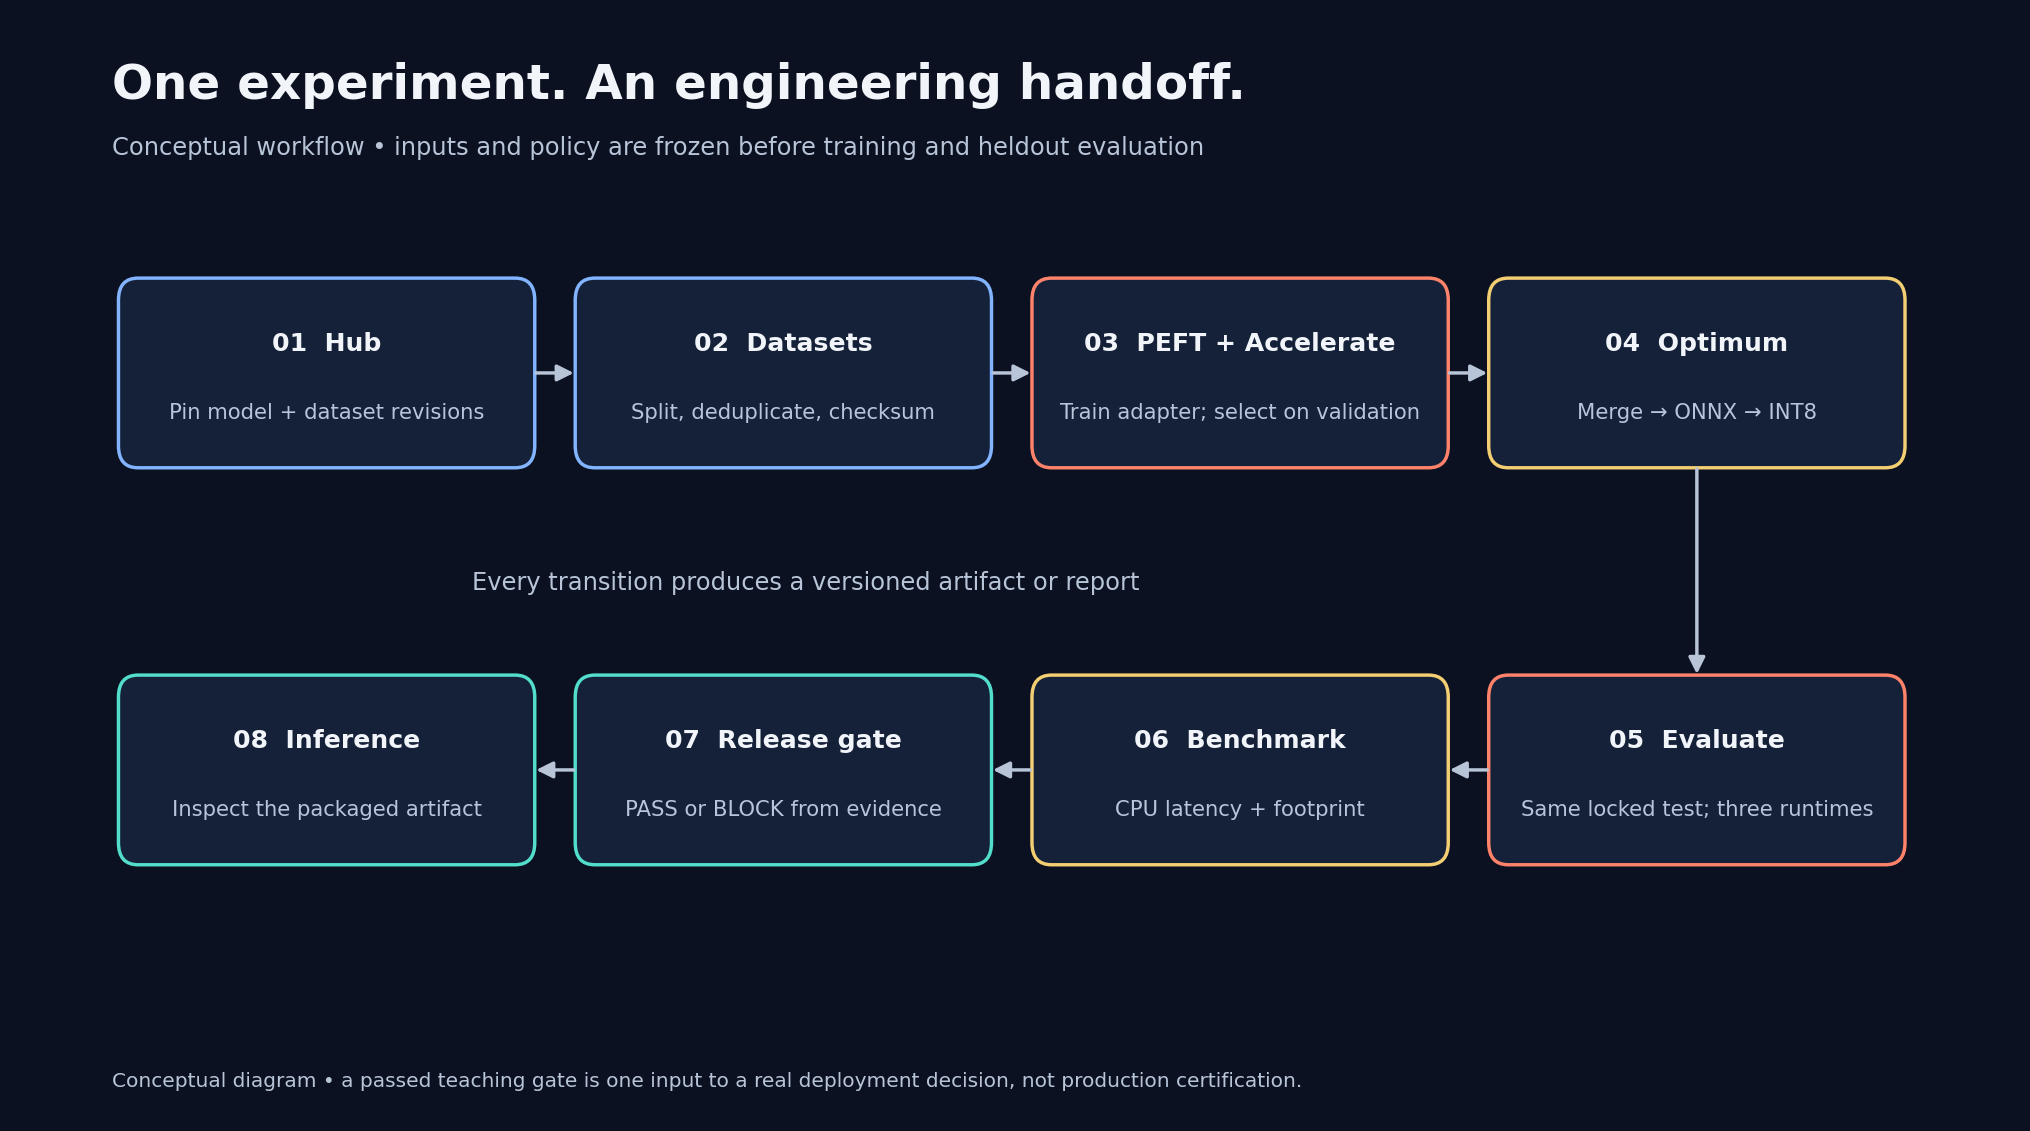

In [3]:
torch_version = importlib.metadata.version('torch')
PYENV = BASE / 'bringing-the-heat-colab-env'
command([sys.executable, '-m', 'venv', '--system-site-packages', '--without-pip', PYENV],
        log_name='create_environment')
PYTHON = PYENV / ('Scripts/python.exe' if os.name == 'nt' else 'bin/python')
# Also supports a local Jupyter kernel that is itself in a virtual environment.
child_site = subprocess.check_output([str(PYTHON), '-c',
    "import sysconfig; print(sysconfig.get_paths()['purelib'])"], text=True).strip()
(Path(child_site) / 'heat_runtime_packages.pth').write_text(
    '\n'.join(site.getsitepackages()) + '\n', encoding='utf-8')
(WORK / 'runtime-constraints.txt').write_text(f'torch=={torch_version}\n', encoding='utf-8')
command([sys.executable, '-m', 'pip', '--python', PYTHON, 'install', '--quiet',
         '--disable-pip-version-check', '--no-warn-conflicts',
         '-r', WORK / 'requirements-colab.txt', '-c', WORK / 'runtime-constraints.txt'],
        log_name='install')

def run(*args, allowed=(0,)):
    return command([PYTHON, WORK / 'demo.py', *args],
                   log_name='-'.join(str(arg).replace('--', '') for arg in args[:2]), allowed=allowed)

command([PYTHON, '-c', '''import torch
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig
from accelerate import Accelerator
from optimum.onnxruntime import ORTModelForSequenceClassification, ORTQuantizer
import datasets, onnxruntime, sklearn, matplotlib
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Training device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU — full training will take longer')
print('Teaching stack imports: PASS')'''], log_name='import_check')

def draw(stage, *figure_names):
    # Render from this run's files in the same pinned environment as the pipeline.
    command([PYTHON, WORK / 'visuals.py', stage, '--root', WORK], log_name=f'plot-{stage}')
    for name in figure_names:
        display(Image(filename=str(WORK / 'figures' / f'{name}.png'), width=1100))

draw('workflow', '01_workflow')


## 2 · Turn Hub objects into reproducible inputs
`prepare` downloads **DistilBERT** and **AG News** at explicit commit revisions. It writes balanced splits once, removes normalized exact duplicates across all splits and hashes every split. Validation comes from the original training split; our test comes from the original test split. Near-duplicate and time/source leakage checks are further production work.

The Hub is more than a download page: model cards, dataset cards, licenses, revisions, adapters and runnable examples all become part of the engineering handoff.



Fetching 5 files: 100%|██████████| 5/5 [00:02<00:00,  1.93it/s]

Generating train split: 100%|██████████| 120000/120000 [00:00<00:00, 626250.76 examples/s]

Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 579608.17 examples/s]
{
  "model_id": "distilbert/distilbert-base-uncased",
  "dataset_id": "fancyzhx/ag_news",
  "model_revision": "12040accade4e8a0f71eabdb258fecc2e7e948be",
  "dataset_revision": "eb185aade064a813bc0b7f42de02595523103ca4",
  "seed": 42,
  "max_length": 128,
  "labels": [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
  ],
  "splits": {
    "train": {
      "count": 3200,
      "sha256": "1b033d9aaba70e652f2fa28784f2dfad9a7be4be3fe0356b5a4a4b234f784ff8",
      "class_counts": [
        800,
        800,
        800,
        800
      ]
    },
    "validation": {
      "count": 400,
      "sha256": "bbd740e09897eb64112112d989eabf910ce12d113d669cd545be3e19f2e4a602",
      "class_counts": [
        100,
        100,
        100,
        100
 

{'train': {'examples': 3200,
  'sha256': '1b033d9aaba70e652f2fa28784f2dfad9a7be4be3fe0356b5a4a4b234f784ff8'},
 'validation': {'examples': 400,
  'sha256': 'bbd740e09897eb64112112d989eabf910ce12d113d669cd545be3e19f2e4a602'},
 'test': {'examples': 800,
  'sha256': '1700db6e66621dcb489759df8c6cce4004334c9815054b9dc6bbfbb293a26721'}}

Model: distilbert/distilbert-base-uncased @ 12040accade4e8a0f71eabdb258fecc2e7e948be
Dataset: fancyzhx/ag_news @ eb185aade064a813bc0b7f42de02595523103ca4
Saved figures/02_splits.png and .svg
[plot-splits] exit=0; elapsed=1.0s


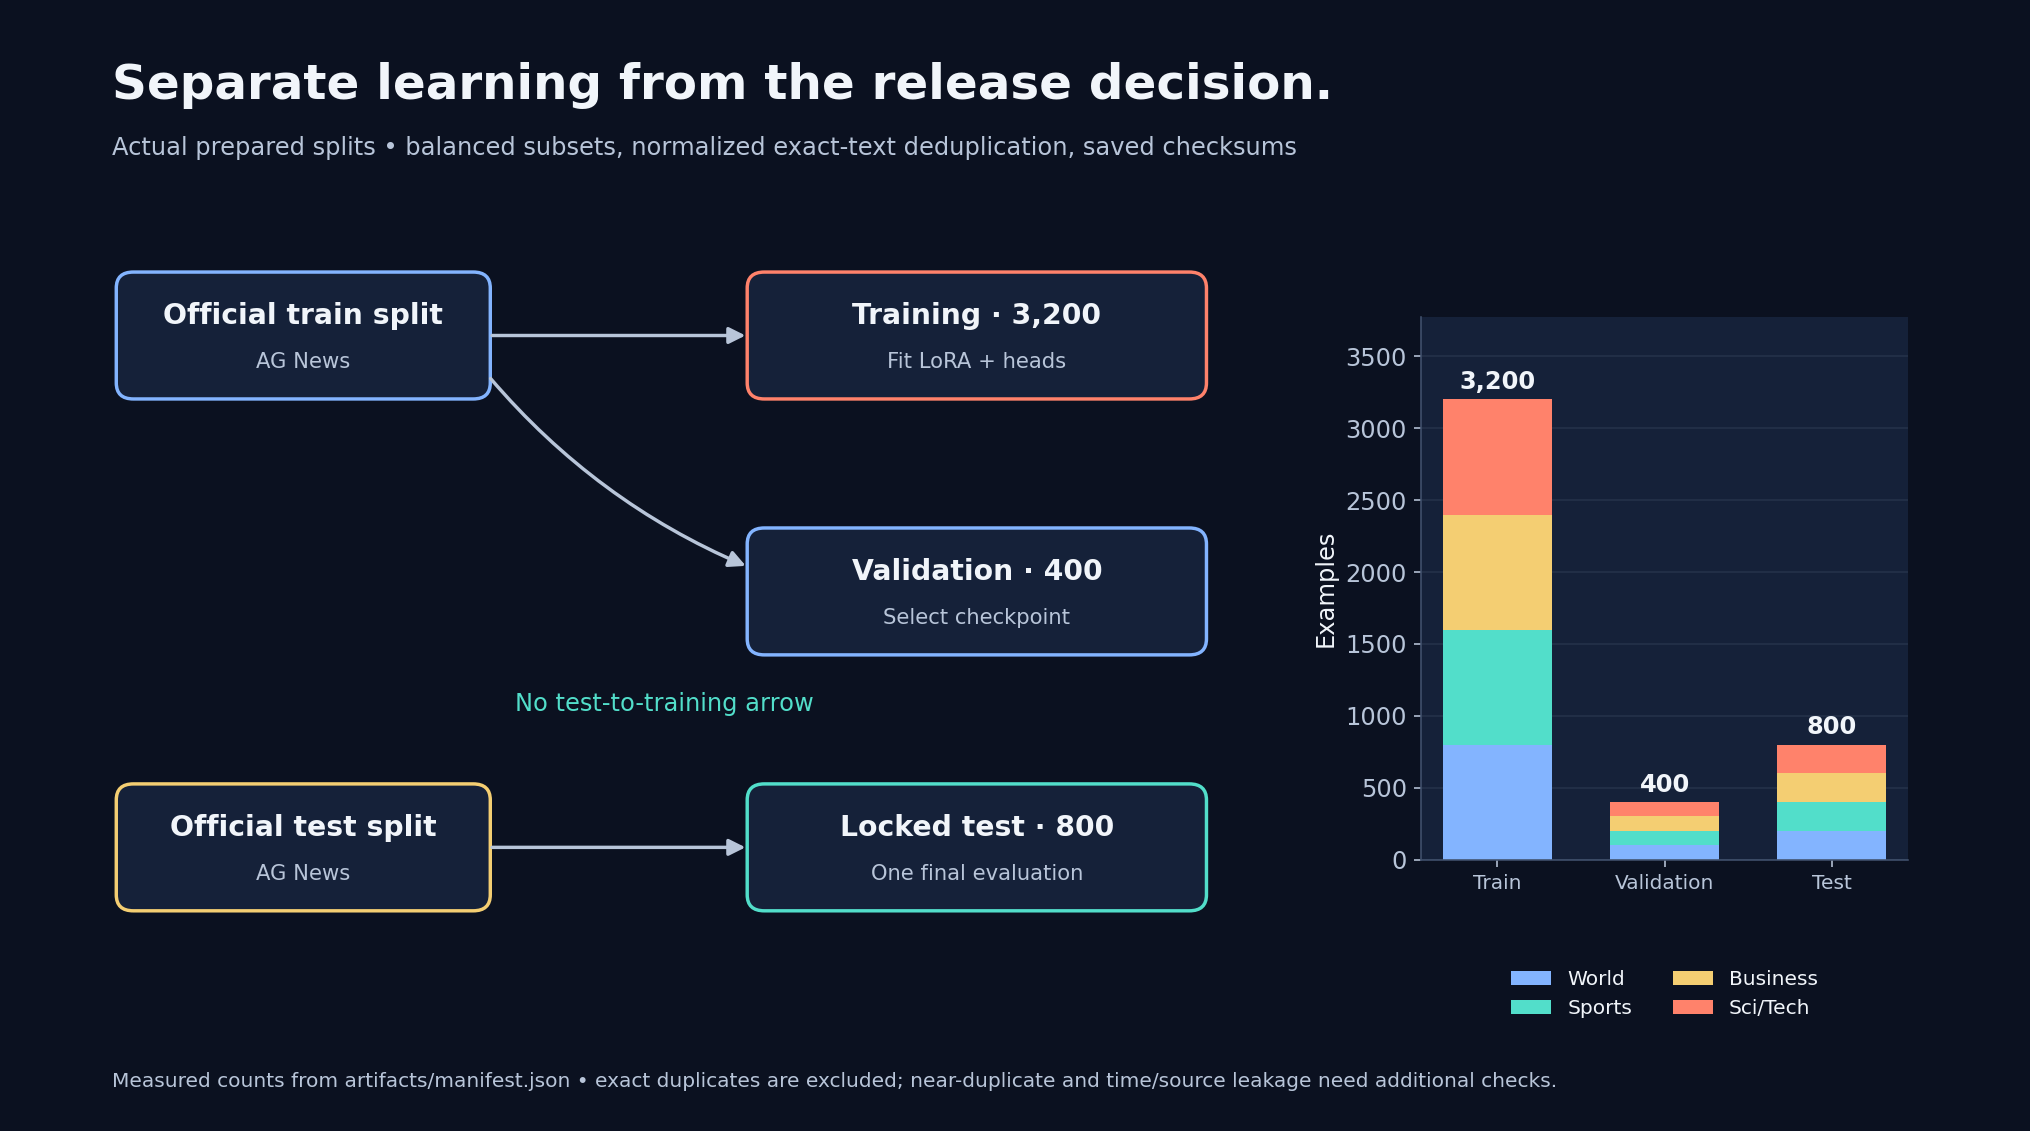

In [4]:
run('prepare')
run('preflight')
manifest = read('artifacts/manifest.json')
display({name: {'examples': split['count'], 'sha256': split['sha256']}
         for name, split in manifest['splits'].items()})
print('Model:', manifest['model_id'], '@', manifest['model_revision'])
print('Dataset:', manifest['dataset_id'], '@', manifest['dataset_revision'])
draw('splits', '02_splits')


## 3 · Train the small part: PEFT + Accelerate
**PEFT controls what learns; Accelerate controls how the training loop runs on the available device.**

```python
config = LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16,
    lora_dropout=0.1, target_modules=['q_lin', 'v_lin'],
    modules_to_save=['pre_classifier', 'classifier'])
model = get_peft_model(base, config)
model, optimizer, train_loader, validation_loader = accelerator.prepare(
    model, optimizer, train_loader, validation_loader)
accelerator.backward(model(**batch).loss)
optimizer.step()
```

We train the low-rank attention updates and classification heads. The rest is frozen. The **best validation macro F1** selects the checkpoint. No test data is used for checkpoint selection. This cell always performs the complete training run, on CUDA if available and CPU otherwise.


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at /content/bringing-the-heat-20260917-181550-581335/artifacts/base_model and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Trainable: 741,124 / 67,697,672 (1.09%)

Map: 100%|██████████| 3200/3200 [00:00<00:00, 5426.54 examples/s]

Map: 100%|██████████| 400/400 [00:00<00:00, 5503.34 examples/s]
Epoch 1/3 step 0/100 loss=1.3952
Epoch 1/3 step 25/100 loss=0.2437
Epoch 1/3 step 50/100 loss=0.1817
Epoch 1/3 step 75/100 loss=0.3469
Validation macro F1: 0.9015
Epoch 2/3 step 0/100 loss=0.3018
Epoch 2/3 step 25/100 loss=0.3639
Epoch 2/3 step 50/100 loss=0.2152
Epoch 2/3 step 75/100 loss=0.2418
Validation macro F1: 0.9001
Epoch 3/3 step 0/100 loss=0.1011
Epoch 3/3 step 25/100 loss=0.0732
Epoch 3/3 step 50/100 loss=0.2435
E

[{'epoch': 1,
  'loss': 0.4991258254647255,
  'validation_macro_f1': 0.9014558517934996},
 {'epoch': 2,
  'loss': 0.2865968254953623,
  'validation_macro_f1': 0.9001123408253887},
 {'epoch': 3,
  'loss': 0.25251735277473925,
  'validation_macro_f1': 0.909692089790283}]

Saved figures/03_lora_budget.png and .svg
Saved figures/04_training_progress.png and .svg
[plot-training] exit=0; elapsed=1.2s


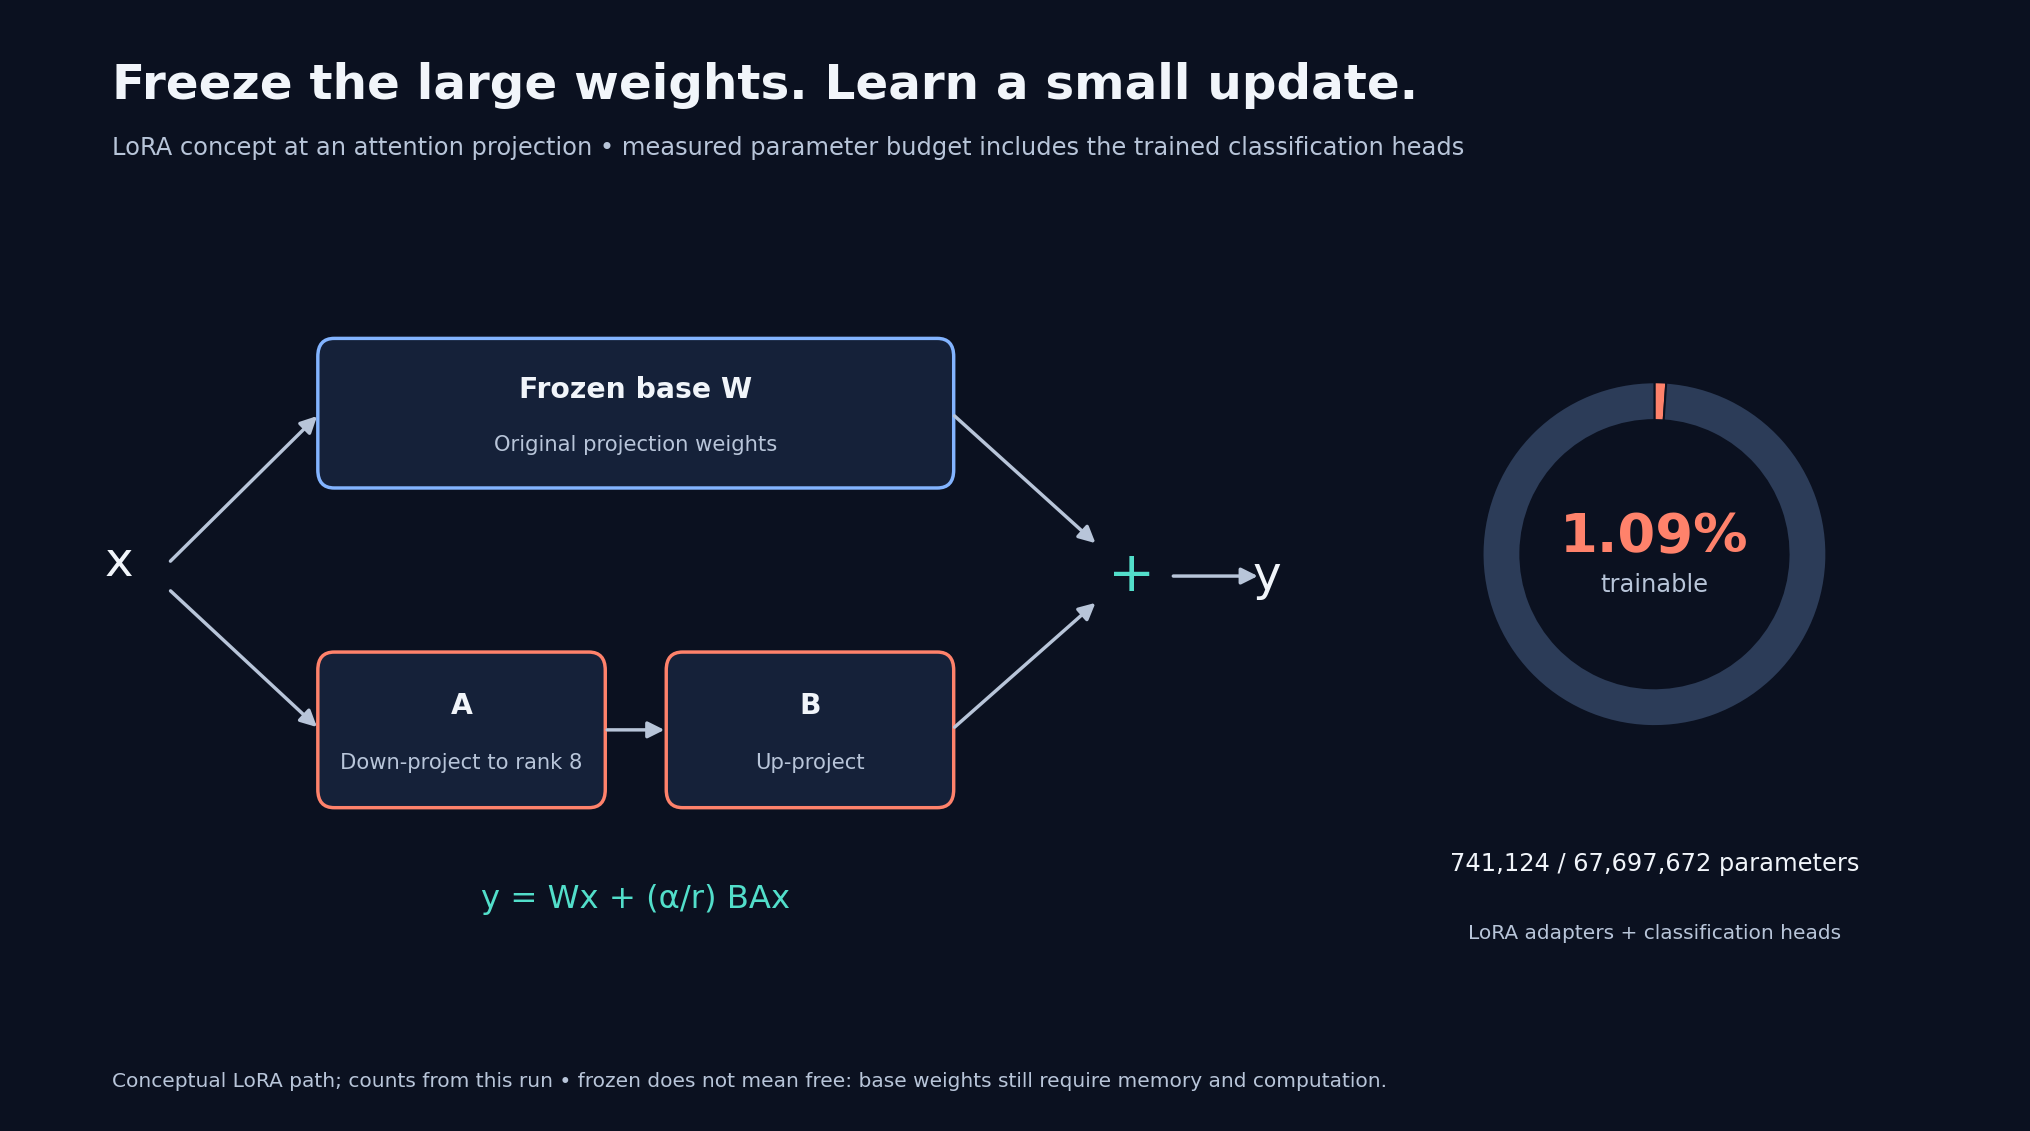

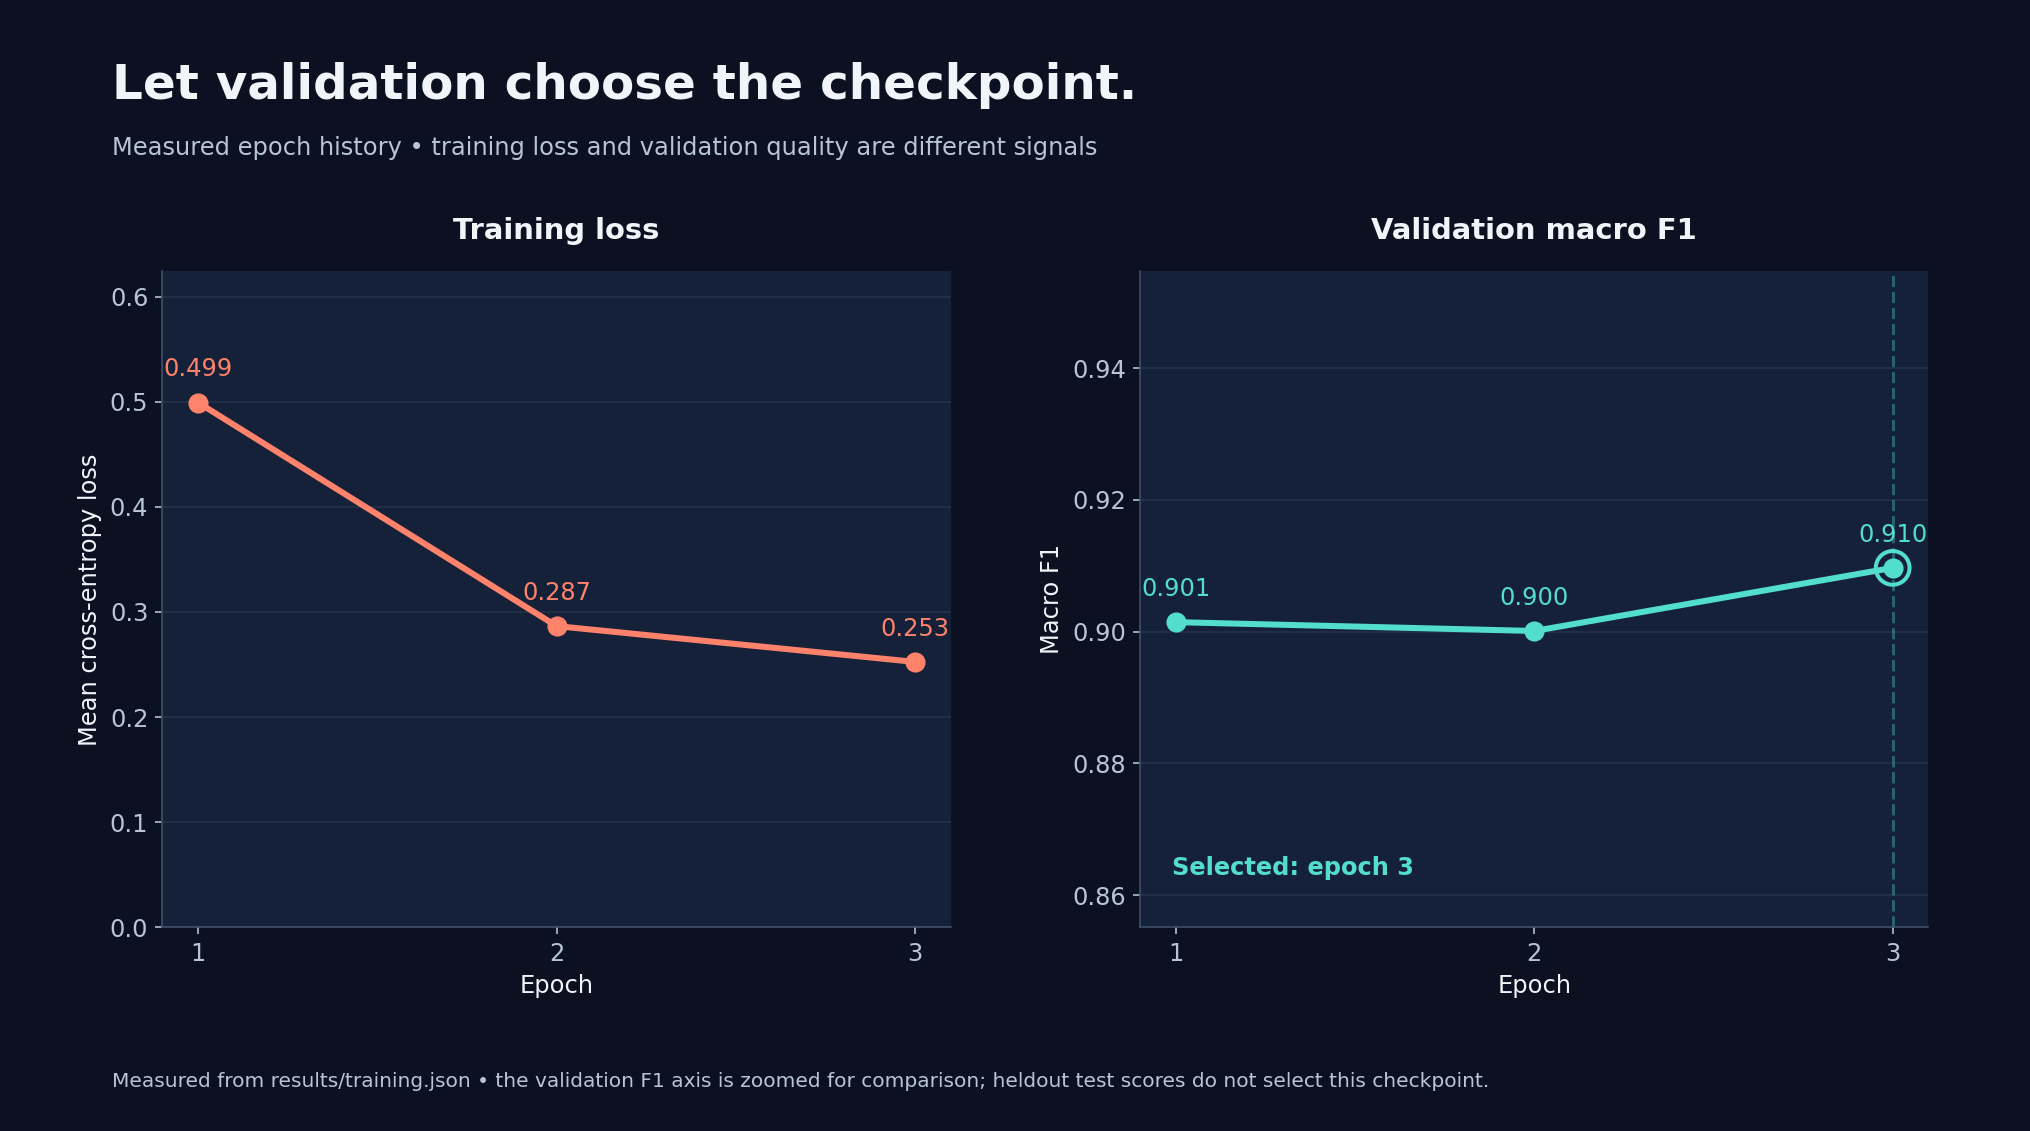

In [5]:
run('train', '--epochs', EPOCHS, '--batch-size', BATCH_SIZE)
training = read('results/training.json')
assert not training['smoke_only'] and training['epochs'] == EPOCHS
print(f"Trainable: {training['trainable_parameters']:,} / {training['total_parameters']:,} ({training['trainable_percent']:.2f}%)")
display([{'epoch': item['epoch'], 'loss': item['mean_loss'],
          'validation_macro_f1': item['validation']['macro_f1']}
         for item in training['history']])
draw('training', '03_lora_budget', '04_training_progress')


## 4 · Export the candidate, then quantize with Optimum
Merge the adapter into the base to produce a standalone model, export ONNX FP32, then apply dynamic INT8 quantization for the x86 AVX2 CPU target. The unmerged adapter remains useful for storage/distribution but requires its base model.

```python
ort_model = ORTModelForSequenceClassification.from_pretrained(merged, export=True)
quantizer = ORTQuantizer.from_pretrained(onnx_fp32)
quantizer.quantize(save_dir=onnx_int8,
    quantization_config=AutoQuantizationConfig.avx2(is_static=False, per_channel=False))
```

INT8 does not guarantee a speedup or unchanged quality. We test the exported artifact, including its packaged tokenizer, next.


Multiple distributions found for package optimum. Picked distribution: optimum
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at /content/bringing-the-heat-20260917-181550-581335/artifacts/base_model and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/content/bringing-the-heat-colab-env/lib/python3.13/site-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  inverted_mask = torch.tensor(1.0, dtype=dtype) - expanded_mask
Merged adapter, exported ONNX FP32, and g

{'adapter': 3.74, 'merged': 256.33, 'onnx_fp32': 256.43, 'onnx_int8': 65.15}

Values above are total packaged MiB, not peak memory.
Saved figures/05_export_footprint.png and .svg
[plot-export] exit=0; elapsed=0.9s


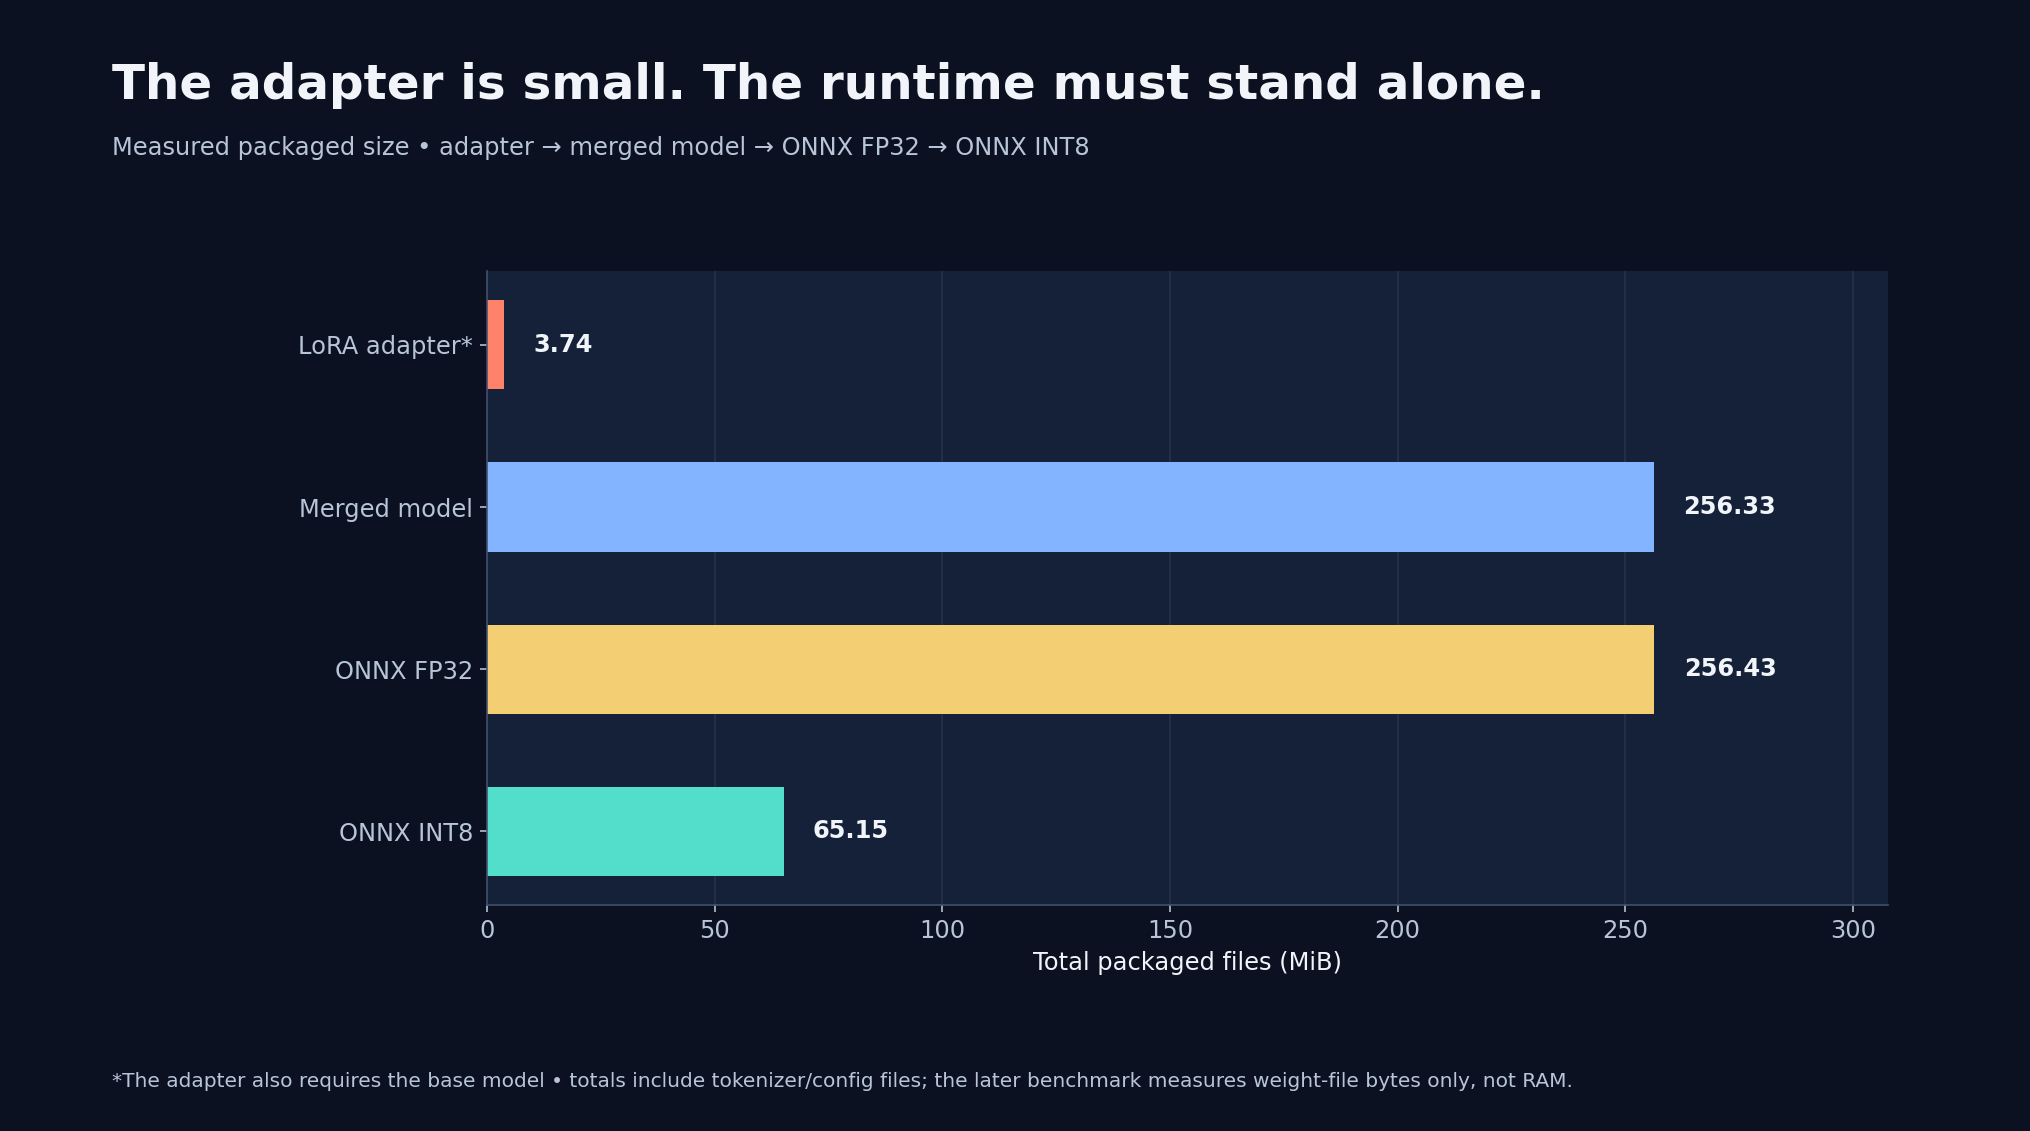

In [6]:
run('export', '--target', 'avx2')
exported = read('results/export.json')
display({name: round(sum(item['bytes'] for item in files.values()) / 1024**2, 2)
         for name, files in exported['artifacts'].items()})
print('Values above are total packaged MiB, not peak memory.')
draw('export', '05_export_footprint')


## 5 · Evaluate the exact artifact on the locked test
Compare PyTorch FP32, ONNX FP32 and ONNX INT8 on the **same 800 examples**, with a majority-class baseline. Macro F1 gives each class equal weight; per-class recall exposes weak slices. The Wilson interval describes sampling uncertainty on this dataset, not tomorrow's distribution shift.


pytorch: accuracy=0.8950, macro F1=0.8947
Multiple distributions found for package optimum. Picked distribution: optimum
onnx: accuracy=0.8950, macro F1=0.8947
int8: accuracy=0.8988, macro F1=0.8986
[evaluate] exit=0; elapsed=693.4s


{'pytorch': {'n': 800, 'accuracy': 0.895, 'macro_f1': 0.8947334935235721},
 'onnx': {'n': 800, 'accuracy': 0.895, 'macro_f1': 0.8947334935235721},
 'int8': {'n': 800, 'accuracy': 0.89875, 'macro_f1': 0.8985763739035568}}

{'majority_class_baseline': {'chosen_label': 'World',
  'rule': 'Most frequent training label; ties choose lowest label index',
  'n': 800,
  'accuracy': 0.25,
  'macro_f1': 0.1,
  'accuracy_95pct_wilson': [0.2212364664027642, 0.28115305909579164],
  'per_class': {'World': {'precision': 0.25,
    'recall': 1.0,
    'f1': 0.4,
    'support': 200},
   'Sports': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 200},
   'Business': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 200},
   'Sci/Tech': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 200}},
  'confusion_matrix': [[200, 0, 0, 0],
   [200, 0, 0, 0],
   [200, 0, 0, 0],
   [200, 0, 0, 0]]}}

{'int8_per_class': {'World': {'precision': 0.9243243243243243,
   'recall': 0.855,
   'f1': 0.8883116883116883,
   'support': 200},
  'Sports': {'precision': 0.9516908212560387,
   'recall': 0.985,
   'f1': 0.9680589680589681,
   'support': 200},
  'Business': {'precision': 0.8356807511737089,
   'recall': 0.89,
   'f1': 0.8619854721549637,
   'support': 200},
  'Sci/Tech': {'precision': 0.8871794871794871,
   'recall': 0.865,
   'f1': 0.8759493670886076,
   'support': 200}}}

INT8 accuracy 95% Wilson interval: [0.8759035400979053, 0.917785166731898]
Saved figures/06_evaluation.png and .svg
[plot-evaluation] exit=0; elapsed=1.0s


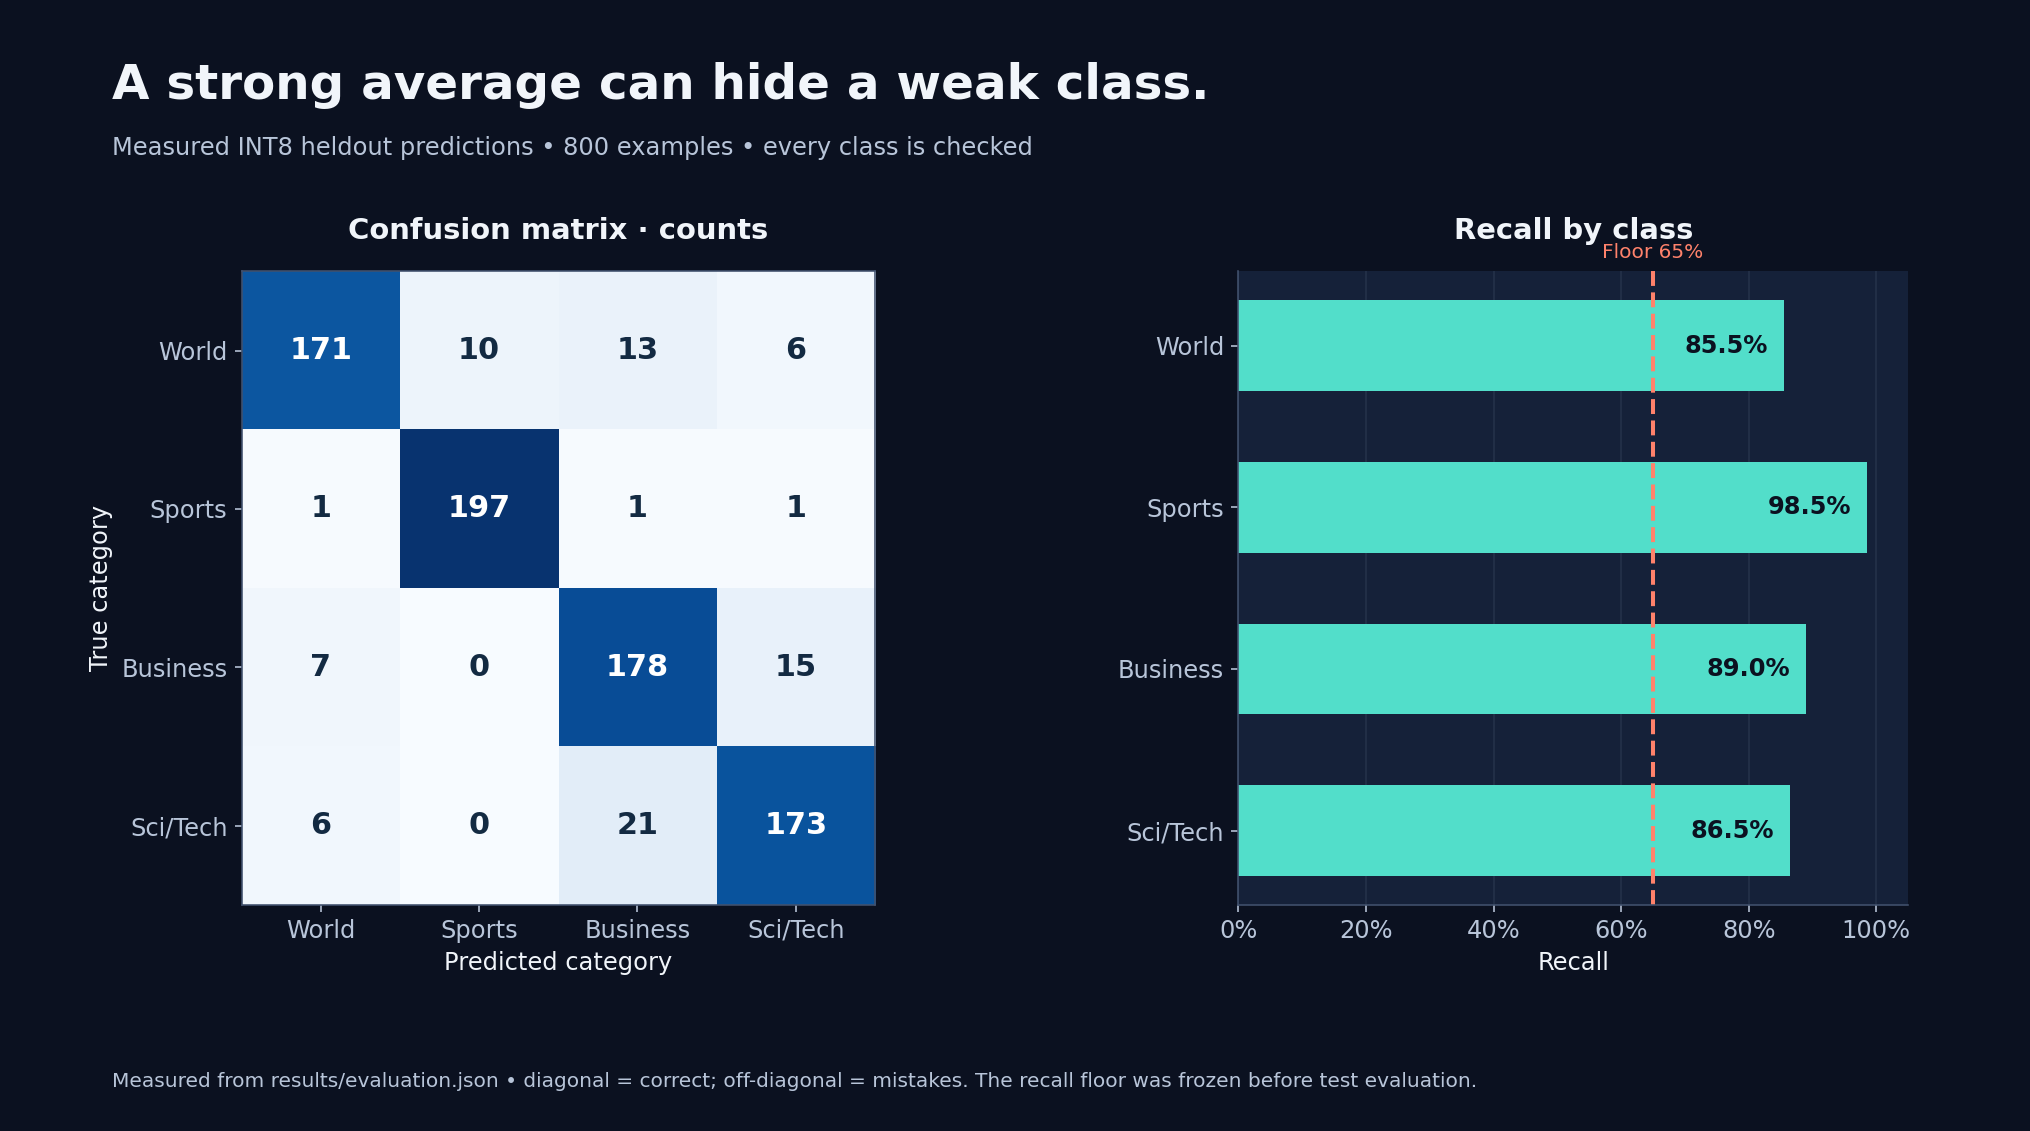

In [7]:
run('evaluate')
evaluation = read('results/evaluation.json')
display({name: {key: score[key] for key in ['n', 'accuracy', 'macro_f1']}
         for name, score in evaluation['models'].items()})
display({'majority_class_baseline': evaluation['majority_class_baseline']})
display({'int8_per_class': evaluation['models']['int8']['per_class']})
print('INT8 accuracy 95% Wilson interval:', evaluation['models']['int8']['accuracy_95pct_wilson'])
draw('evaluation', '06_evaluation')


## 6 · Measure inference on this VM
All three implementations use CPU, the same thread count, batch 1, a fixed padded 128-token input, 10 warmups and 100 sequential requests. Timing includes tokenization + forward and excludes model loading, network and queueing. Disk weight size is not RAM usage. The GPU accelerates training; these measurements isolate CPU inference.

Colab's shared VM is a learning environment. Results will differ from the presenter's laptop and your target device. Keep these measurements with this run's hardware metadata and remeasure on the deployment target.


pytorch: p50=127.62ms, p95=225.21ms, weights=255.4MiB
Multiple distributions found for package optimum. Picked distribution: optimum
onnx: p50=109.38ms, p95=239.20ms, weights=255.5MiB
int8: p50=105.99ms, p95=183.92ms, weights=64.2MiB
[benchmark-threads] exit=0; elapsed=57.5s


{'pytorch': {'p50_ms': 127.62, 'p95_ms': 225.21, 'weights_MiB': 255.43},
 'onnx': {'p50_ms': 109.38, 'p95_ms': 239.2, 'weights_MiB': 255.53},
 'int8': {'p50_ms': 105.99, 'p95_ms': 183.92, 'weights_MiB': 64.25}}

{'python': '3.13.15',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
 'processor': 'x86_64',
 'cpu_logical_count': 2,
 'cuda_available': True,
 'gpu': 'Tesla T4',
 'packages': {'torch': '2.11.0+cu128',
  'transformers': '4.55.4',
  'peft': '0.17.1',
  'accelerate': '1.10.1',
  'datasets': '4.0.0',
  'optimum-onnx': '0.0.3',
  'onnxruntime': '1.30.0',
  'scikit-learn': '1.7.2',
  'gradio': '6.26.0'}}

Saved figures/07_latency.png and .svg
Saved figures/08_quality_size.png and .svg
[plot-benchmark] exit=0; elapsed=1.6s


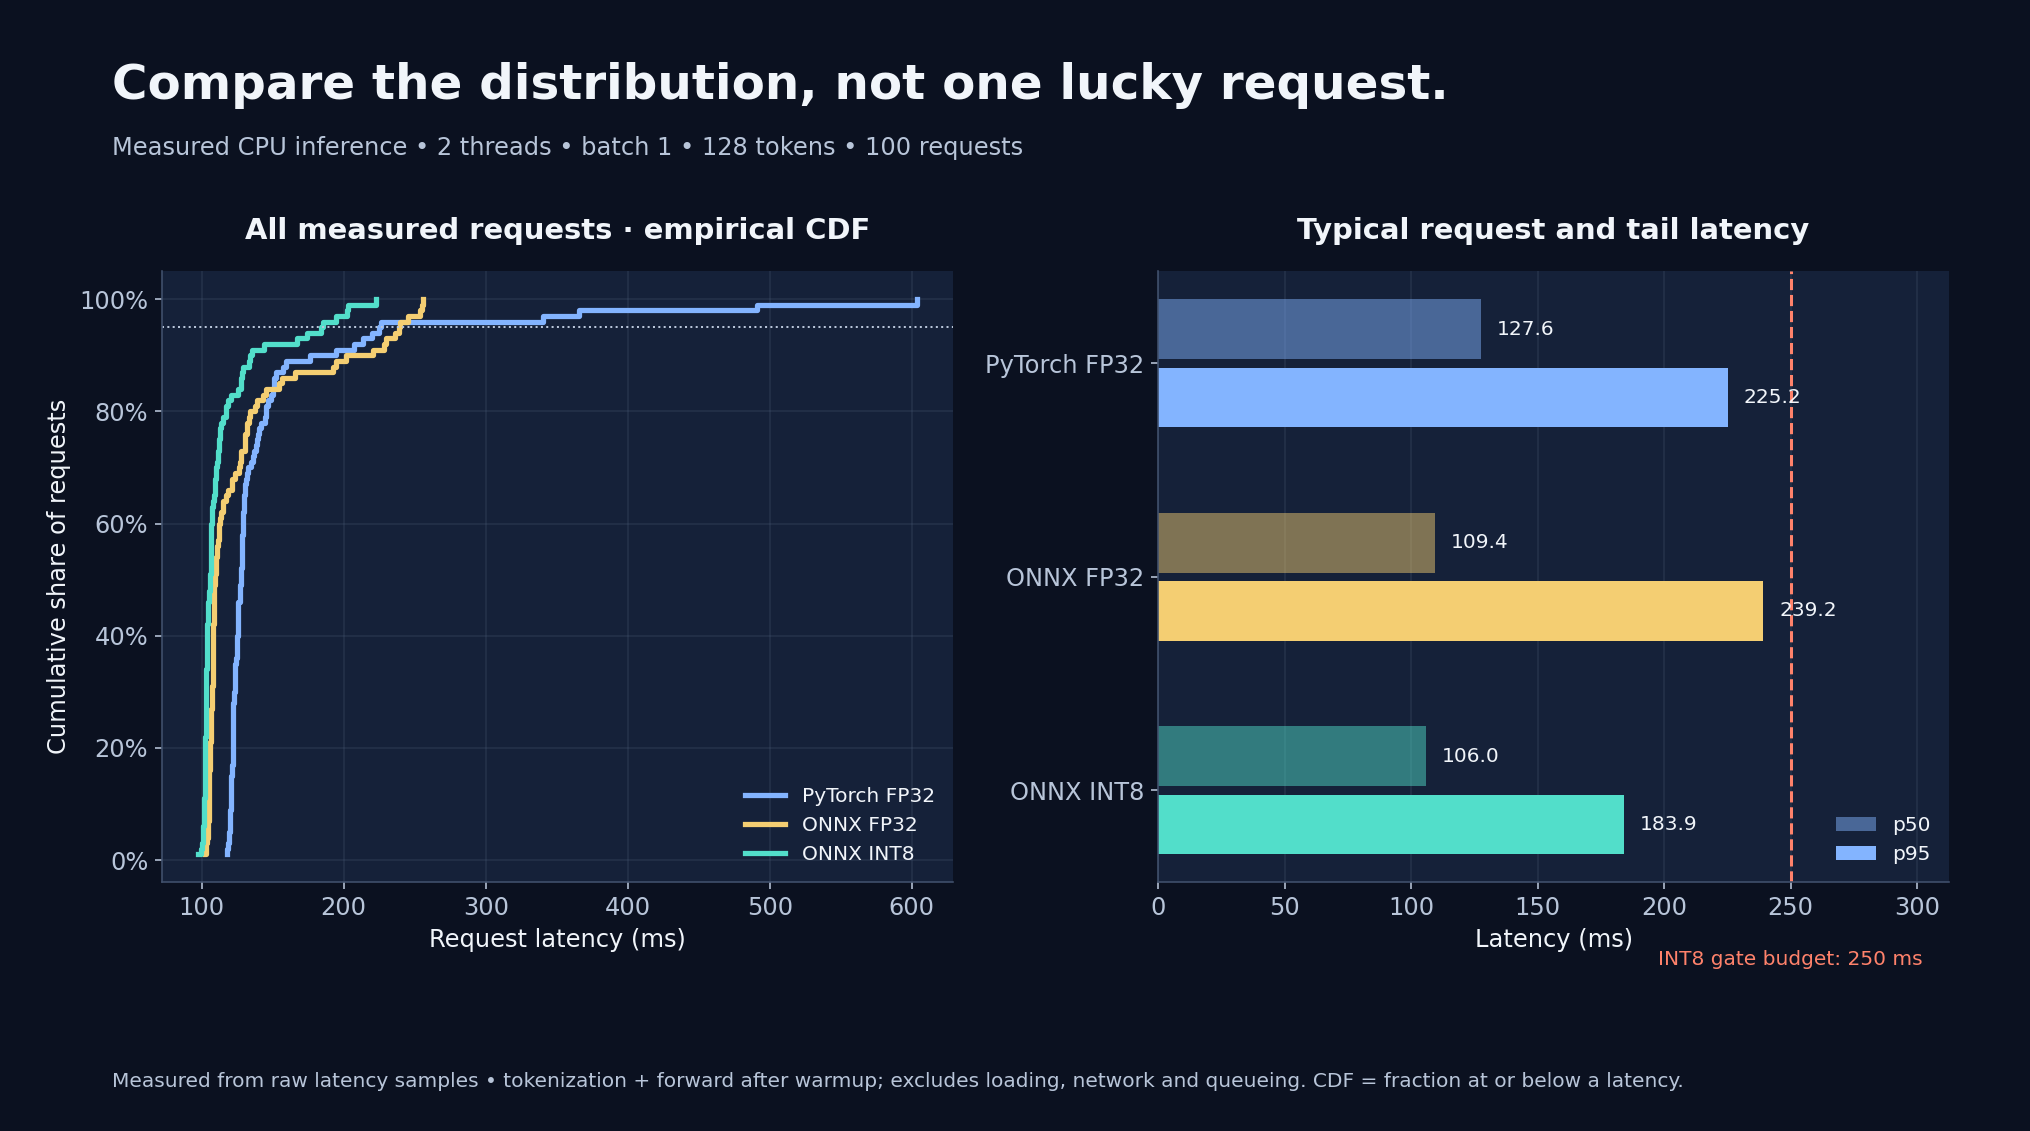

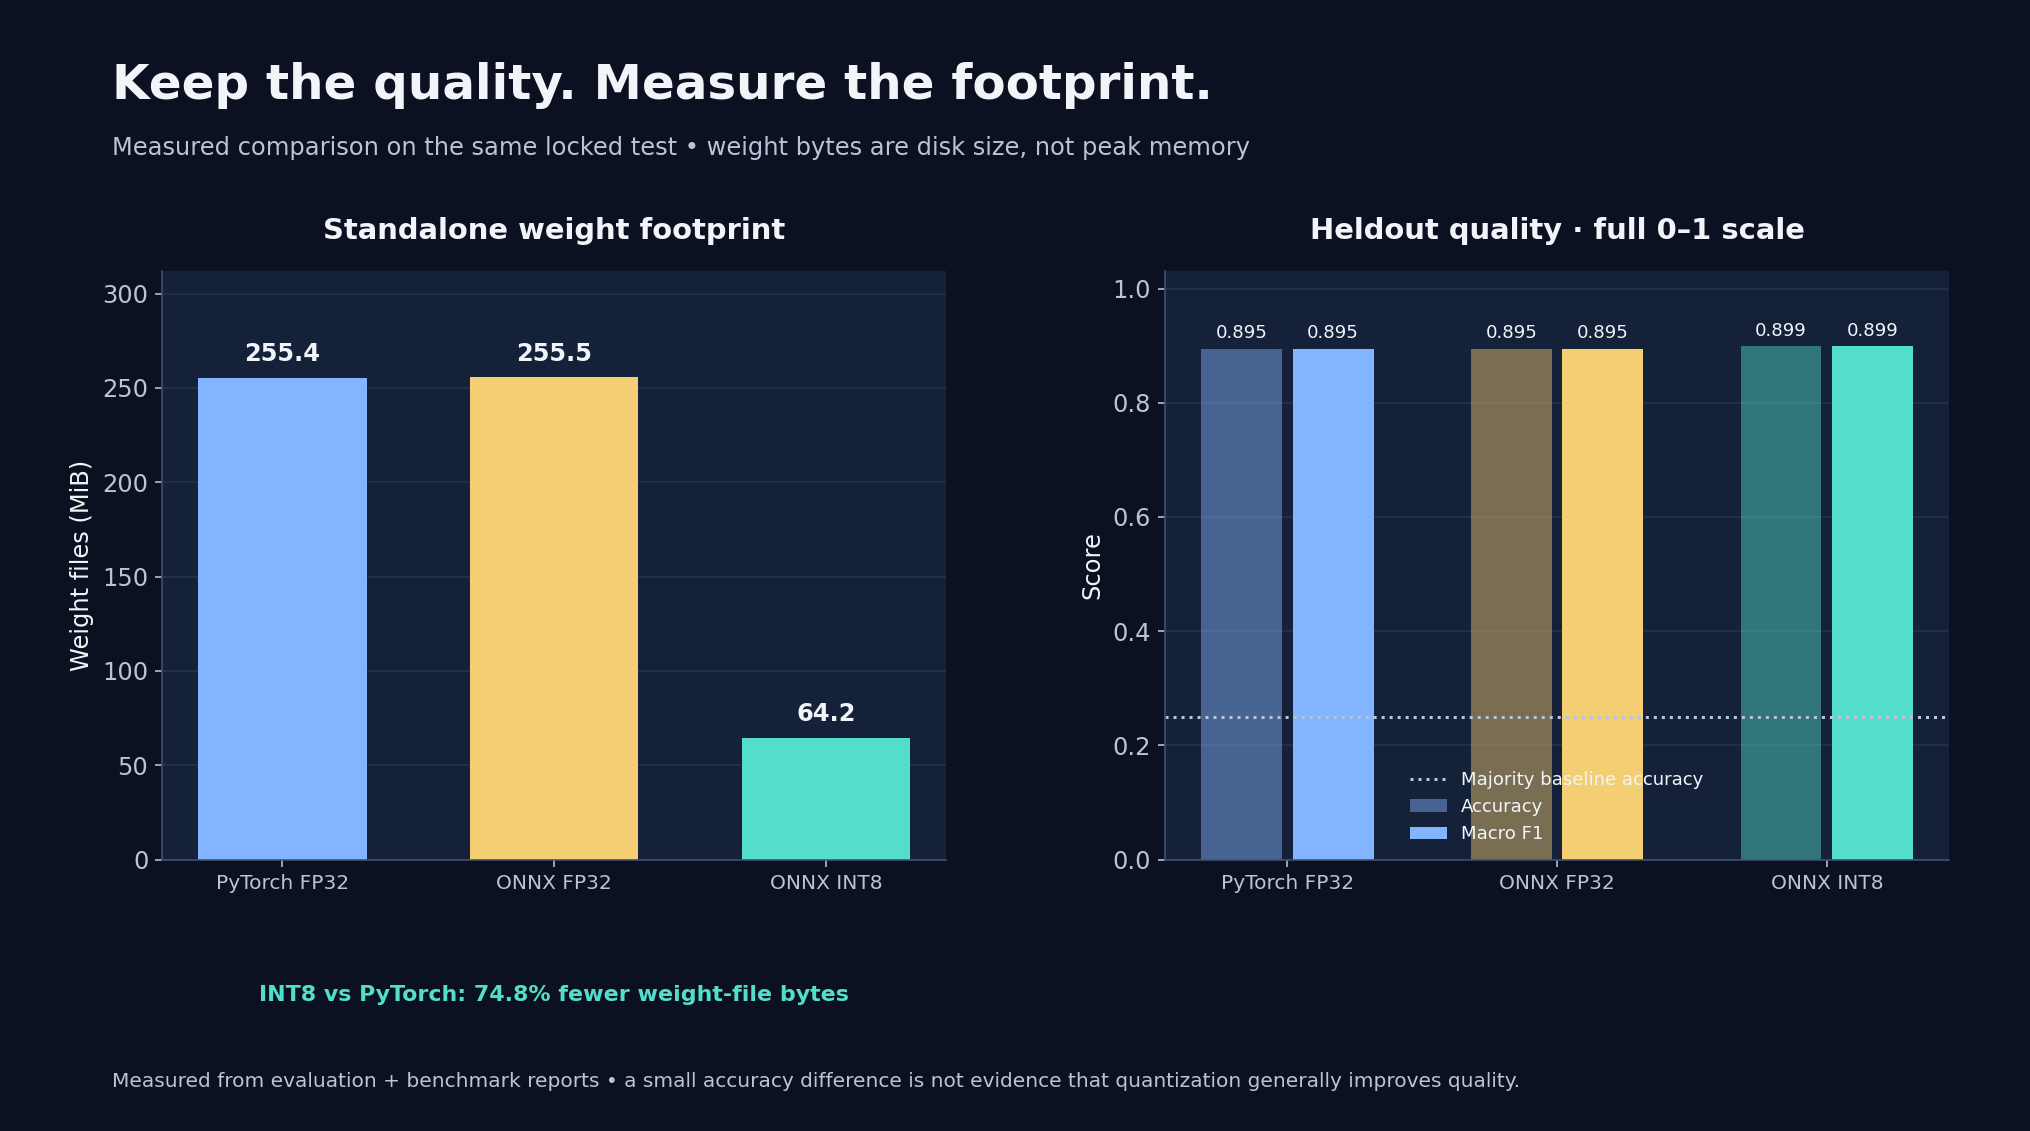

In [8]:
run('benchmark', '--threads', BENCHMARK_THREADS, '--samples', 100, '--warmup', 10)
benchmark = read('results/benchmark.json')
display({name: {'p50_ms': round(score['p50_ms'], 2), 'p95_ms': round(score['p95_ms'], 2),
                'weights_MiB': round(score['weights_bytes'] / 1024**2, 2)}
         for name, score in benchmark['models'].items()})
display(benchmark['environment'])
draw('benchmark', '07_latency', '08_quality_size')


## 7 · Make the release decision executable
The gate checks quality, every-class recall, quantization regression, sample size, footprint, the frozen CPU timing budget, the measurement protocol, and hashes of the exact runtime files.

**PASS and BLOCK are both valid results.** Unexpected execution failures still stop the notebook. We then inject a simulated Business-recall failure and require it to block, without modifying the real evaluation report. The illustrative policy is not production certification.


{
  "passed": true,
  "checks": {
    "same_heldout_split": true,
    "exact_runtime_artifacts": true,
    "complete_class_report": true,
    "benchmark_protocol": true,
    "minimum_test_size": true,
    "accuracy": true,
    "macro_f1": true,
    "every_class_recall": true,
    "quantization_f1_regression": true,
    "cpu_p95_latency": true,
    "weight_size": true
  },
  "policy": {
    "policy_scope": "Colab teaching policy; measurements belong to this VM, not a production or edge SLA",
    "min_test_examples": 800,
    "min_accuracy": 0.8,
    "min_macro_f1": 0.8,
    "min_class_recall": 0.65,
    "max_macro_f1_drop": 0.02,
    "benchmark_threads": 2,
    "max_cpu_p95_ms": 250.0,
    "max_weights_bytes": 104857600
  },
  "injected_failure": false,
  "scope": "Teaching gate on this locked sample and CPU; not a production certification"
}
[gate] exit=0; elapsed=1.8s


### Teaching gate: PASS

{'same_heldout_split': True,
 'exact_runtime_artifacts': True,
 'complete_class_report': True,
 'benchmark_protocol': True,
 'minimum_test_size': True,
 'accuracy': True,
 'macro_f1': True,
 'every_class_recall': True,
 'quantization_f1_regression': True,
 'cpu_p95_latency': True,
 'weight_size': True}

{
  "passed": false,
  "checks": {
    "same_heldout_split": true,
    "exact_runtime_artifacts": true,
    "complete_class_report": true,
    "benchmark_protocol": true,
    "minimum_test_size": true,
    "accuracy": true,
    "macro_f1": true,
    "every_class_recall": false,
    "quantization_f1_regression": true,
    "cpu_p95_latency": true,
    "weight_size": true
  },
  "policy": {
    "policy_scope": "Colab teaching policy; measurements belong to this VM, not a production or edge SLA",
    "min_test_examples": 800,
    "min_accuracy": 0.8,
    "min_macro_f1": 0.8,
    "min_class_recall": 0.65,
    "max_macro_f1_drop": 0.02,
    "benchmark_threads": 2,
    "max_cpu_p95_ms": 250.0,
    "max_weights_bytes": 104857600
  },
  "injected_failure": true,
  "scope": "Teaching gate on this locked sample and CPU; not a production certification"
}
[gate-inject-failure] exit=2; elapsed=1.8s
Deliberate slice regression was blocked correctly.
Saved figures/09_release_gate.png and .svg
[plot-ga

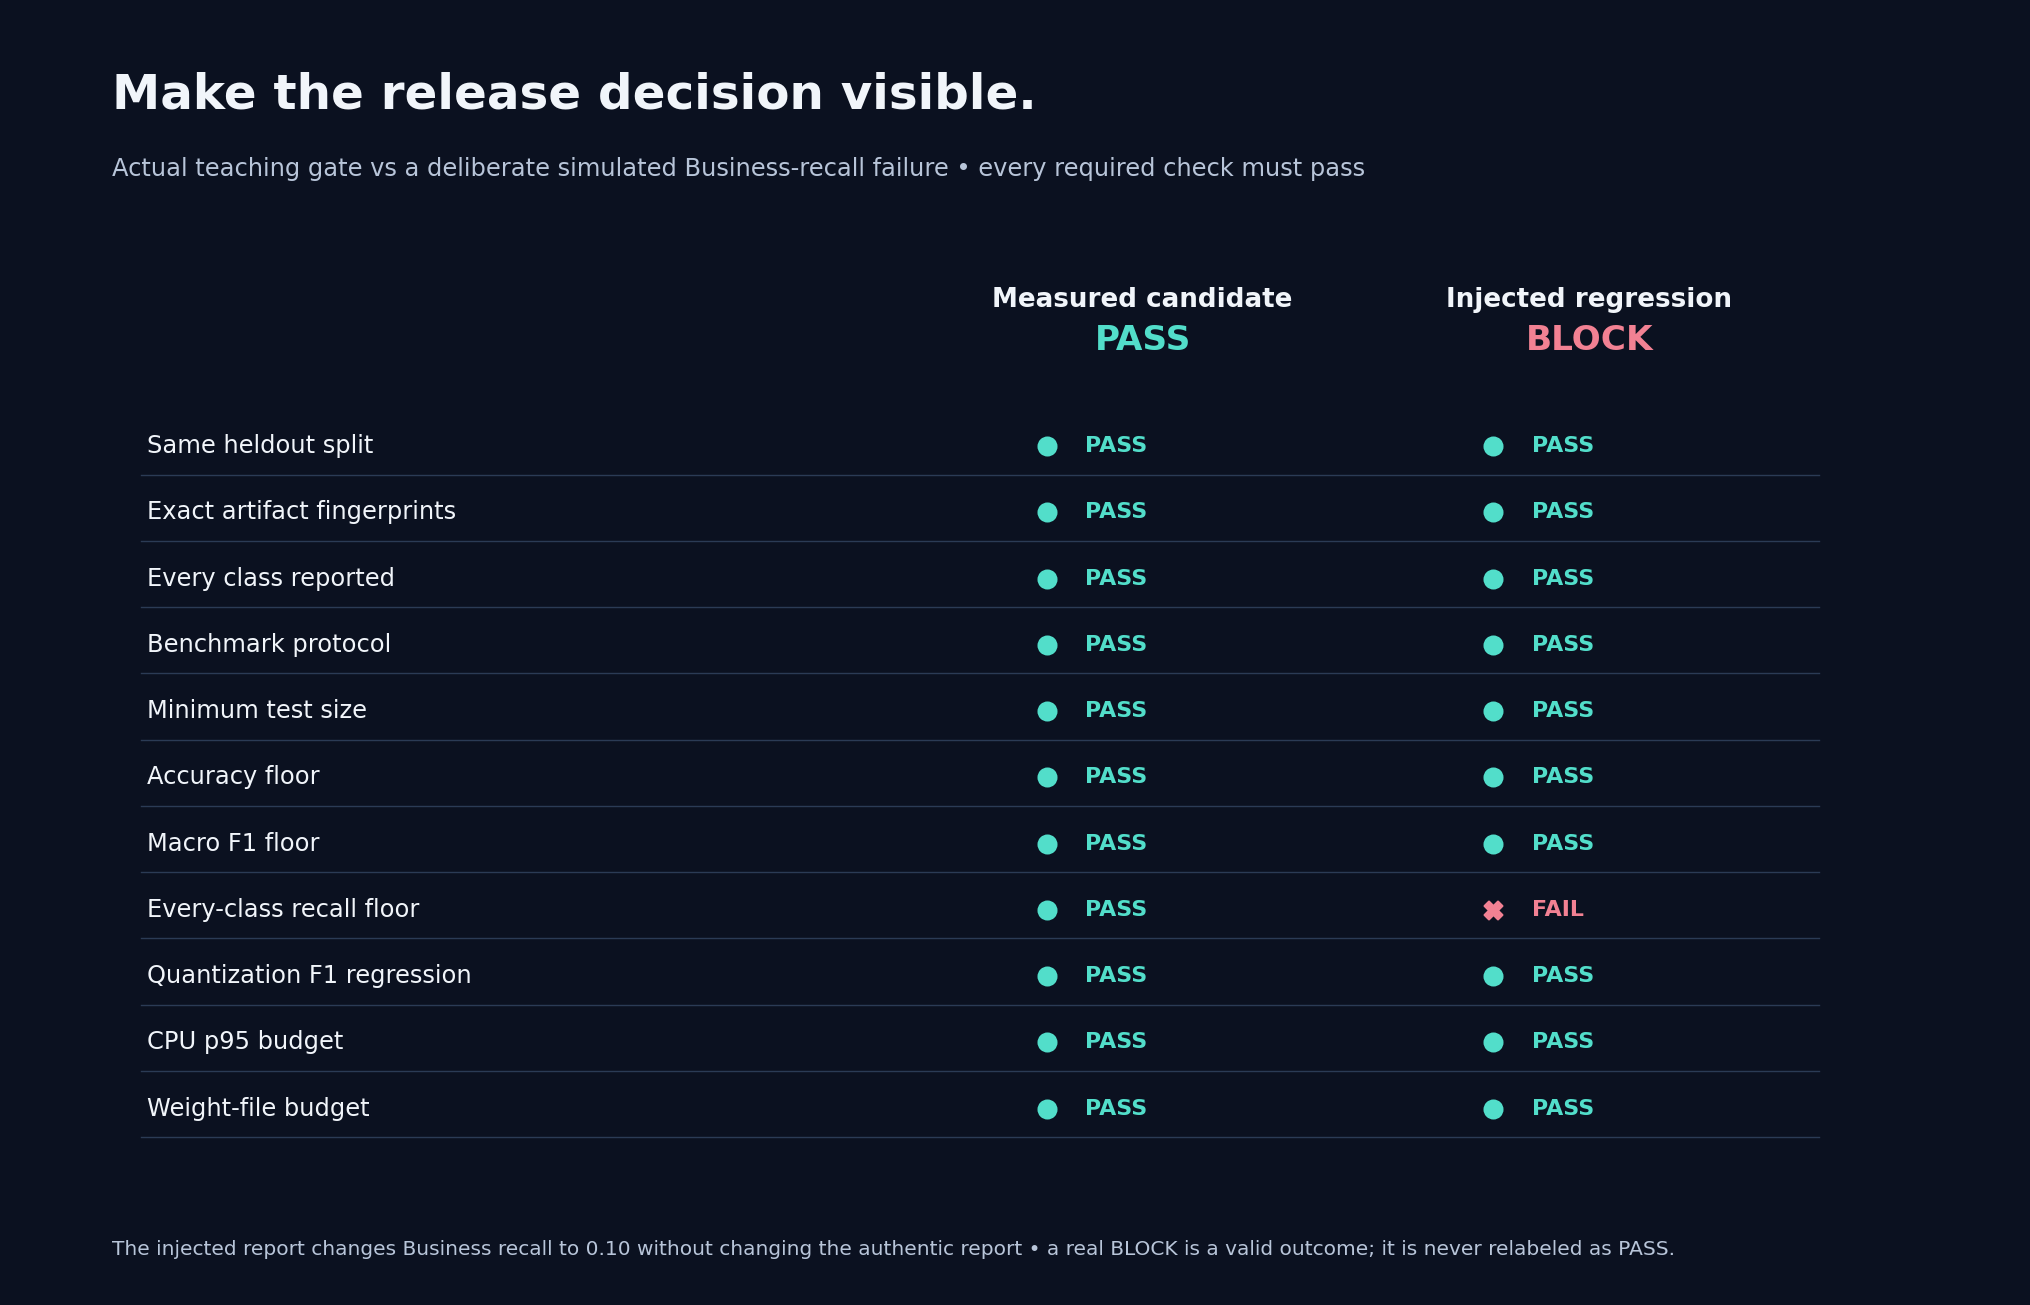

In [9]:
gate_exit = run('gate', allowed=(0, 2))
gate = read('results/gate.json')
assert gate['passed'] == (gate_exit == 0)
display(Markdown('### Teaching gate: ' + ('PASS' if gate['passed'] else 'BLOCK')))
display(gate['checks'])
run('gate', '--inject-failure', allowed=(2,))
injected = read('results/gate_deliberate_failure.json')
assert not injected['checks']['every_class_recall'] and not injected['passed']
print('Deliberate slice regression was blocked correctly.')
draw('gates', '09_release_gate')


## 8 · Inference with the packaged INT8 artifact
This cell exercises the same exported model directly inside the notebook. Edit `HEADLINES` and rerun it to try your own examples. There is no external web server or public Gradio tunnel.

Scores are not calibrated confidence. The model always chooses one of four categories; it has no “unknown” class, and input is truncated to 128 tokens. A blocked candidate can still be inspected here; the teaching gate does not authorize a deployment.


Multiple distributions found for package optimum. Picked distribution: optimum
{
  "backend": "onnx_int8",
  "artifact": {
    "sha256": "f7745043e97246793cd89b1fa0341e35349c846bd5fa6eff5ba29c5b02e0dba1",
    "files": {
      "config.json": "2621fc586373cf114f6592e6a49429bb14349a9d26ec0072c99fc4d086a8b4bc",
      "model_quantized.onnx": "9cfac96ba62cd7ae5510bd2dce1a8224a0ce9598c7feef95bdfe81a81e21c06b",
      "ort_config.json": "62a98e992faf1b0af04e290a749ee1ea087cef9cd758615fc7b3cebf2446da1d",
      "special_tokens_map.json": "b6d346be366a7d1d48332dbc9fdf3bf8960b5d879522b7799ddba59e76237ee3",
      "tokenizer.json": "d241a60d5e8f04cc1b2b3e9ef7a4921b27bf526d9f6050ab90f9267a1f9e5c66",
      "tokenizer_config.json": "a3c9410f27554c6e26af779fd147e536c6c5f9e5cb0e6b8f38ddaa25e1b0f6af",
      "vocab.txt": "07eced375cec144d27c900241f3e339478dec958f92fddbc551f295c992038a3"
    },
    "max_length": 128,
    "truncation": true,
    "label_order": [
      "World",
      "Sports",
      "Business"

[{'text': 'The Miami team won the championship after a dramatic final quarter.',
  'label': 'Sports',
  'scores': {'World': 0.004324177745729685,
   'Sports': 0.9912737011909485,
   'Business': 0.0038488872814923525,
   'Sci/Tech': 0.0005532603827305138}},
 {'text': 'Shares climbed after the company reported higher quarterly earnings.',
  'label': 'Business',
  'scores': {'World': 0.010276718996465206,
   'Sports': 0.0004751763481181115,
   'Business': 0.9839106798171997,
   'Sci/Tech': 0.005337489768862724}},
 {'text': 'Scientists unveiled a new processor for energy-efficient computing.',
  'label': 'Sci/Tech',
  'scores': {'World': 0.00865967757999897,
   'Sports': 0.0002597396378405392,
   'Business': 0.035234589129686356,
   'Sci/Tech': 0.9558460116386414}},
 {'text': 'Leaders met for talks on a new international peace agreement.',
  'label': 'World',
  'scores': {'World': 0.9687193632125854,
   'Sports': 0.0040551163256168365,
   'Business': 0.023900335654616356,
   'Sci/Tech': 0.

Saved figures/10_inference.png and .svg
[plot-inference] exit=0; elapsed=1.1s


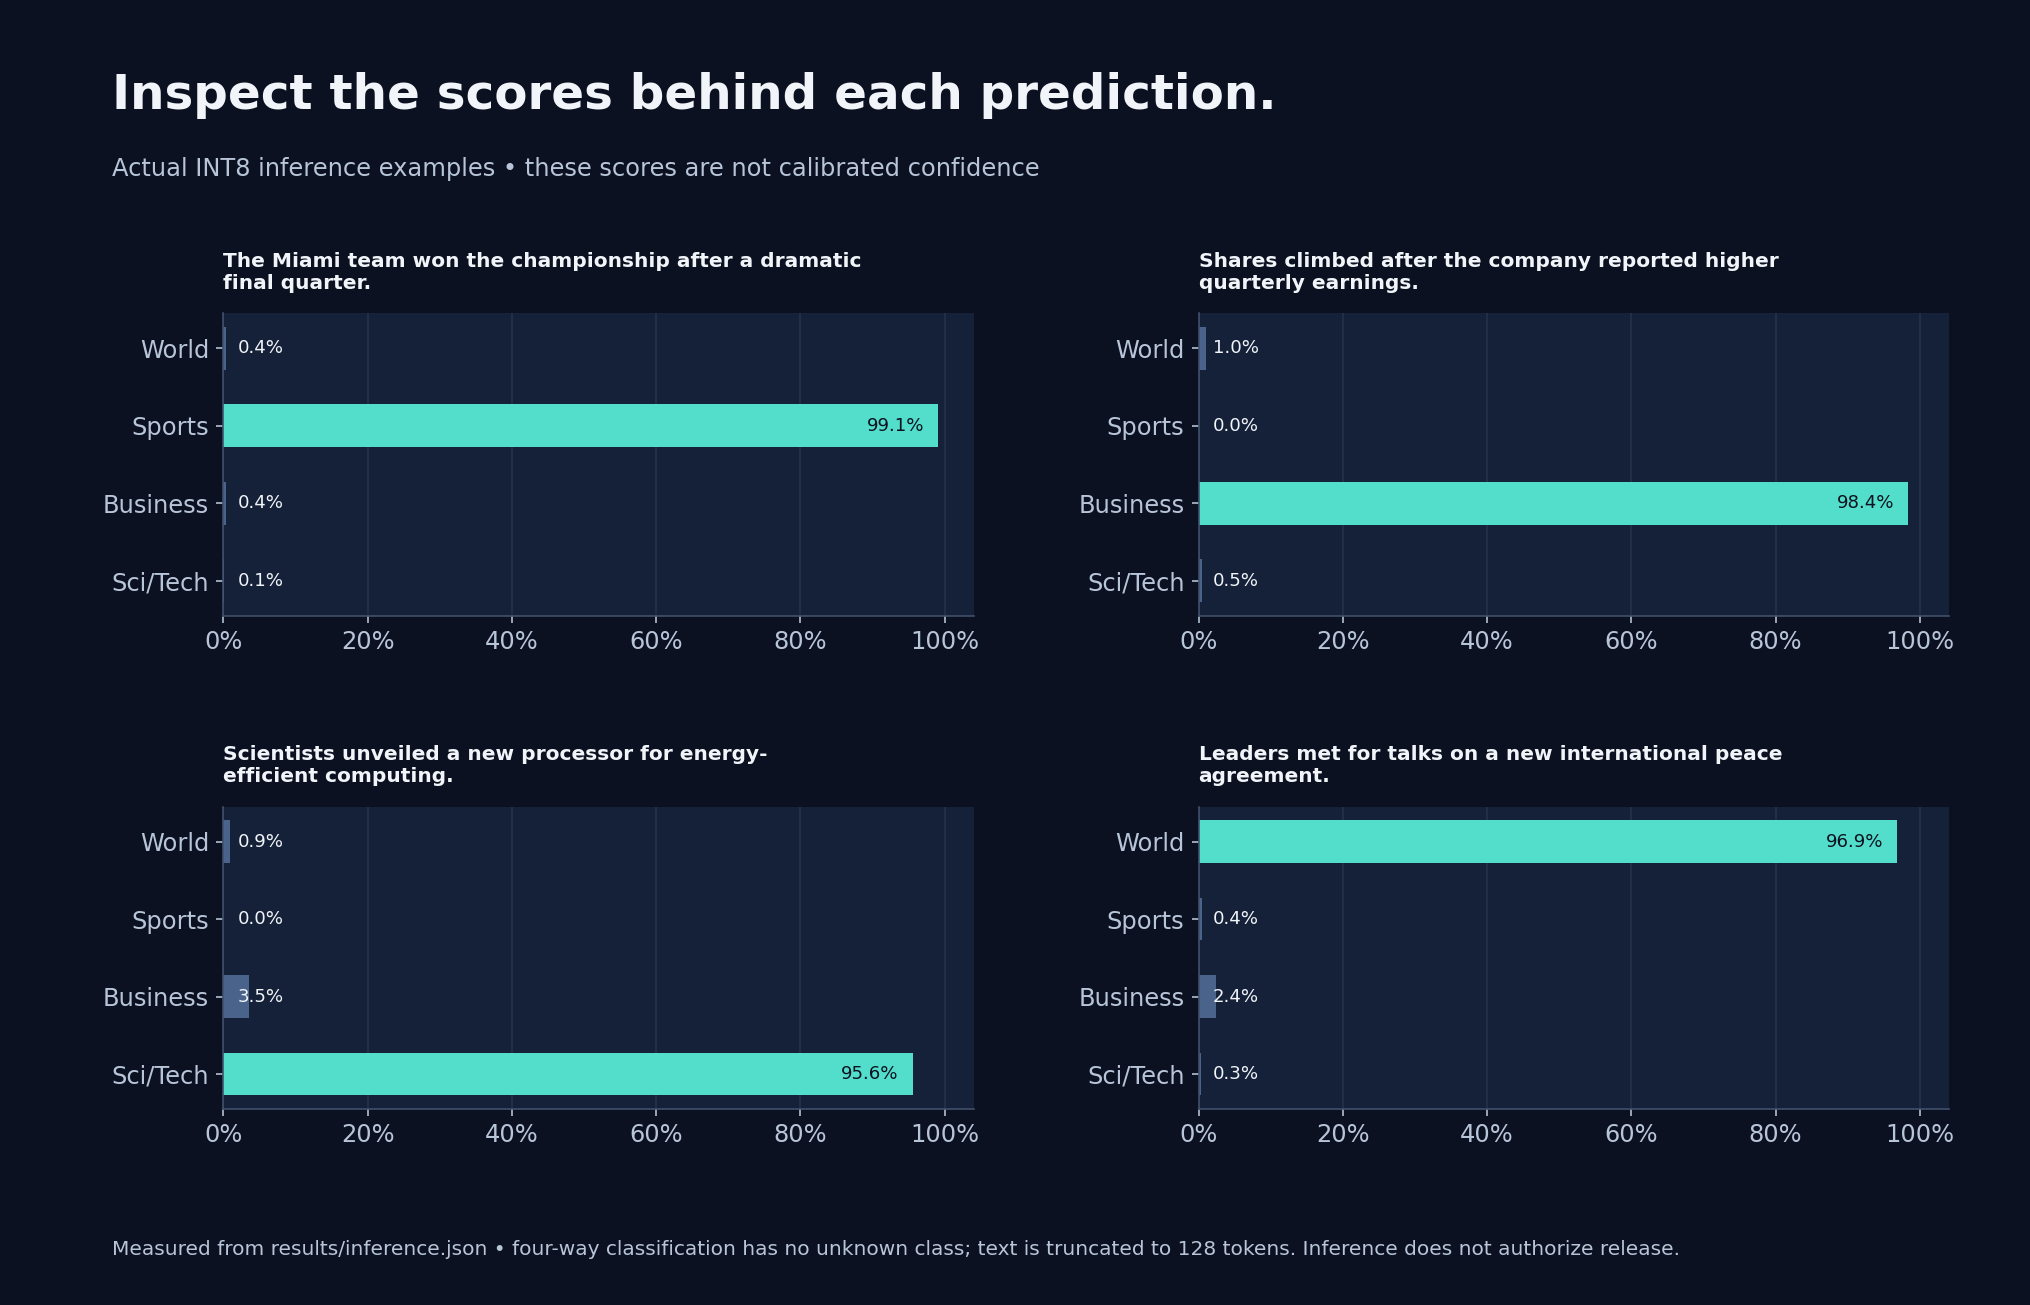

In [10]:
HEADLINES = [
    'The Miami team won the championship after a dramatic final quarter.',
    'Shares climbed after the company reported higher quarterly earnings.',
    'Scientists unveiled a new processor for energy-efficient computing.',
    'Leaders met for talks on a new international peace agreement.',
]
predict_args = ['predict', '--threads', BENCHMARK_THREADS]
for headline in HEADLINES:
    predict_args.extend(['--text', headline])
run(*predict_args)
display(read('results/inference.json')['predictions'])
draw('inference', '10_inference')


## 9 · Keep the evidence and artifact
The bundle contains the measured INT8 runtime, tokenizer, adapter, pinned-input manifest, source, policy, JSON reports, and every visual as **PNG + SVG**. The workflow and LoRA path are conceptual diagrams; numerical charts are generated from this run's actual results. It excludes the base/merged FP32 weights and raw dataset. Download it using Colab's **Files** sidebar before the runtime expires. Set `DOWNLOAD_NOW=True` for an immediate browser download.

For a real rollout, this handoff still needs a deployment target, service limits, authentication, concurrent load tests, observability, staged rollout and rollback. Colab hosts the exercise; it is not your production serving platform.


In [11]:
complete = {
    'status': 'ALL_PIPELINE_STAGES_COMPLETED', 'run_label': RUN_LABEL,
    'completed_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(),
    'source_sha256': BUNDLED_SHA256,
    'training_epochs': training['epochs'], 'smoke_only': training['smoke_only'],
    'environment': benchmark['environment'], 'gate_passed': gate['passed'],
    'deliberate_failure_blocked': not injected['passed'],
    'inference_examples': len(read('results/inference.json')['predictions']),
    'visuals': read('figures/provenance.json'),
}
(WORK / 'results' / 'run_complete.json').write_text(json.dumps(complete, indent=2) + '\n', encoding='utf-8')
BUNDLE = BASE / f'bringing-the-heat-colab-{RUN_LABEL}.zip'
files = [WORK / name for name in ['demo.py', 'visuals.py', 'hub_revisions.json', 'requirements-colab.txt',
    'release_policy.json', 'source_manifest.json', 'artifacts/manifest.json']]
for folder in ['results', 'figures', 'artifacts/adapter', 'artifacts/onnx_int8']:
    files.extend(path for path in (WORK / folder).rglob('*') if path.is_file() and '.cache' not in path.parts)
with zipfile.ZipFile(BUNDLE, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for path in files:
        archive.write(path, path.relative_to(WORK))
display(complete)
print(f'Bundle ready: {BUNDLE} ({BUNDLE.stat().st_size / 1024**2:.1f} MiB)')
DOWNLOAD_NOW = False
if DOWNLOAD_NOW:
    from google.colab import files as colab_files
    colab_files.download(str(BUNDLE))


{'status': 'ALL_PIPELINE_STAGES_COMPLETED',
 'run_label': '20260917-181550-581335',
 'completed_utc': '2026-09-17T18:31:38.551918+00:00',
 'source_sha256': {'demo.py': 'fcb33be9f65bbb6ae7c66bc2276f4e867e43e39ff02553fbfced605e4e16f967',
  'visuals.py': '885031906ac9fe3c8bb15e339f5c314f519868fde5fa7a4388c2cdde11136bc1',
  'hub_revisions.json': '12c749a913590c8548fe58d1993d70e19d504ab2dbdecb34fda0f2c7df9ca808',
  'requirements-colab.txt': '902b32e77a316a27d220ec1c879e3bde709e2b8e6da3749de92866e26c970b35',
  'colab_policy.json': '619185f5a200de8c8268f8b3720fd6859685bcc9bb573532cec3a8e0c501fef5'},
 'training_epochs': 3,
 'smoke_only': False,
 'environment': {'python': '3.13.15',
  'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
  'processor': 'x86_64',
  'cpu_logical_count': 2,
  'cuda_available': True,
  'gpu': 'Tesla T4',
  'packages': {'torch': '2.11.0+cu128',
   'transformers': '4.55.4',
   'peft': '0.17.1',
   'accelerate': '1.10.1',
   'datasets': '4.0.0',
   'optimum-onnx': '0.0.

Bundle ready: /content/bringing-the-heat-colab-20260917-181550-581335.zip (43.8 MiB)


## Take it further
- Change LoRA rank using validation, add a difficult slice and freeze a new policy before evaluating a fresh heldout set.
- Rebenchmark the exported runtime on the real edge device. ARM64 needs a different export/quantization target.
- Use Accelerate's multi-GPU launcher on a suitable host; keep effective batch size constant. DDP replicates this model; it does not provide model sharding or an inference server.
- For LLMs, separately choose quantization, sharding, batching and a serving runtime appropriate to the model and hardware.

**Official references:** [Colab FAQ](https://research.google.com/colaboratory/faq.html) · [Colab runtime versions](https://github.com/googlecolab/backend-info) · [Accelerate](https://huggingface.co/docs/accelerate/quicktour) · [PEFT LoRA](https://huggingface.co/docs/peft/developer_guides/lora) · [Optimum ONNX](https://huggingface.co/docs/optimum-onnx) · [AG News](https://huggingface.co/datasets/fancyzhx/ag_news) · [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased)
